# 06 — Retrieval method comparison

Comparison of 268 retrieval configurations on the golden dataset (20 court
decisions, 195 verbatim quotes). Configurations cover both flat and
hierarchical retrieval, several chunking strategies, embedding models,
BM25 / dense / hybrid methods, the reranker, and `top_k` choice.

In every chart I change one variable at a time and keep the rest fixed,
or compare via Pareto curves so the trade-off between quote recall and
the amount of text sent to the LLM is visible.

Structure:

1. Chunking Pareto — chunking strategy (dense, OpenAI-S, w=0)
2. Methods Pareto — retrieval method (PARA chunking, OpenAI-S)
3. Reranker before / after — effect of the domain reranker
4. Top-k progression — `top_k` choice on the final pipeline
5. Hier vs. flat — architecture at comparable coverage
6. Global overview — all 268 experiments + production config

Bonus: BM25 / dense per-document complementarity, **PAPER FIGURE 5**
(2×2 grid for the paper), **TABLE 2** milestones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, re

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SUMMARY = pd.read_csv('../data/05_retrieval_evaluation/experiment_results_summary.csv', sep=';')
DETAILS = pd.read_csv('../data/05_retrieval_evaluation/experiment_results_details.csv', sep=';')

FIGURES_DIR = '../data/05_retrieval_evaluation/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Family extraction: strip both flat suffix (_topX_wY) and hier suffix (_fkX_c1pY_c2pZ)
def extract_family(name):
    name = re.sub(r'_top\d+_w\d+$', '', name)
    name = re.sub(r'_fk\d+_c1p\d+_c2p\d+$', '', name)
    return name

SUMMARY['family'] = SUMMARY['experiment_name'].apply(extract_family)
SUMMARY['is_hier'] = SUMMARY['family'].str.contains('hier', case=False, na=False)
FINAL_EXP = 'hybrid_a7_reranked_top7_w0'

def pareto_envelope(df, x_col='weighted_total_cov', y_col='recall_rate_percent'):
    sub = df.sort_values(x_col).reset_index(drop=True)
    px, py, best = [], [], -np.inf
    for _, row in sub.iterrows():
        if row[y_col] > best:
            px.append(row[x_col])
            py.append(row[y_col])
            best = row[y_col]
    return px, py

n_total = len(SUMMARY)
n_flat = (~SUMMARY['is_hier']).sum()
n_hier = SUMMARY['is_hier'].sum()
print(f'Total experiments: {n_total} ({n_flat} flat + {n_hier} hierarchical)')
print(f'Hier families: {sorted(SUMMARY[SUMMARY["is_hier"]]["family"].unique().tolist())}')

Total experiments: 268 (158 flat + 110 hierarchical)
Hier families: ['hier_me5_bm25', 'hier_me5_dense', 'hier_me5_hybrid', 'hier_openai_dense', 'hier_openai_hybrid']


---
## 1. Chunking Pareto (w=0 + w=1) + matched-coverage

Only chunking changes here, everything else stays fixed (dense retrieval,
OpenAI-S embedding). Window is the second axis: w=0 is filled markers,
w=1 is empty.

Why include w=1? In my retrieval notes I have window expansion tagged as
a "brute force" way to grow coverage. To give fixed-size a fair shot at
competing with PARA in the high-coverage regime, I let it use w=1. If
fixed-size still cannot beat PARA, the conclusion is defensible.

Numbers from the Pareto envelope (best of w=0 + w=1 per family):
- at cov 30 %: Fixed 500t (50.6 %) > PARA (44.5 %) — 500t wins slightly
- at cov 40 %: Fixed 500t (62.3 %) ~ PARA (61.6 %) — comparable
- at cov 50 %: Fixed 500t (68.9 %) < PARA (73.8 %) — PARA +4.9 pp
- at cov 60 %: Fixed 500t (73.3 %) < PARA (81.7 %) — PARA +8.4 pp
- at cov 65 %: Fixed 500t cannot reach (max 63.5 %) → only PARA (85.5 %)

Conclusion: at cov ≥ 50 % PARA dominates by +6-8 pp and is the only one
that reaches cov ≥ 65 %. Window expansion on fixed-size does not change
that, it only adds non-selective context from neighbours. For a target
recall ≥ 85 % PARA is the only choice.

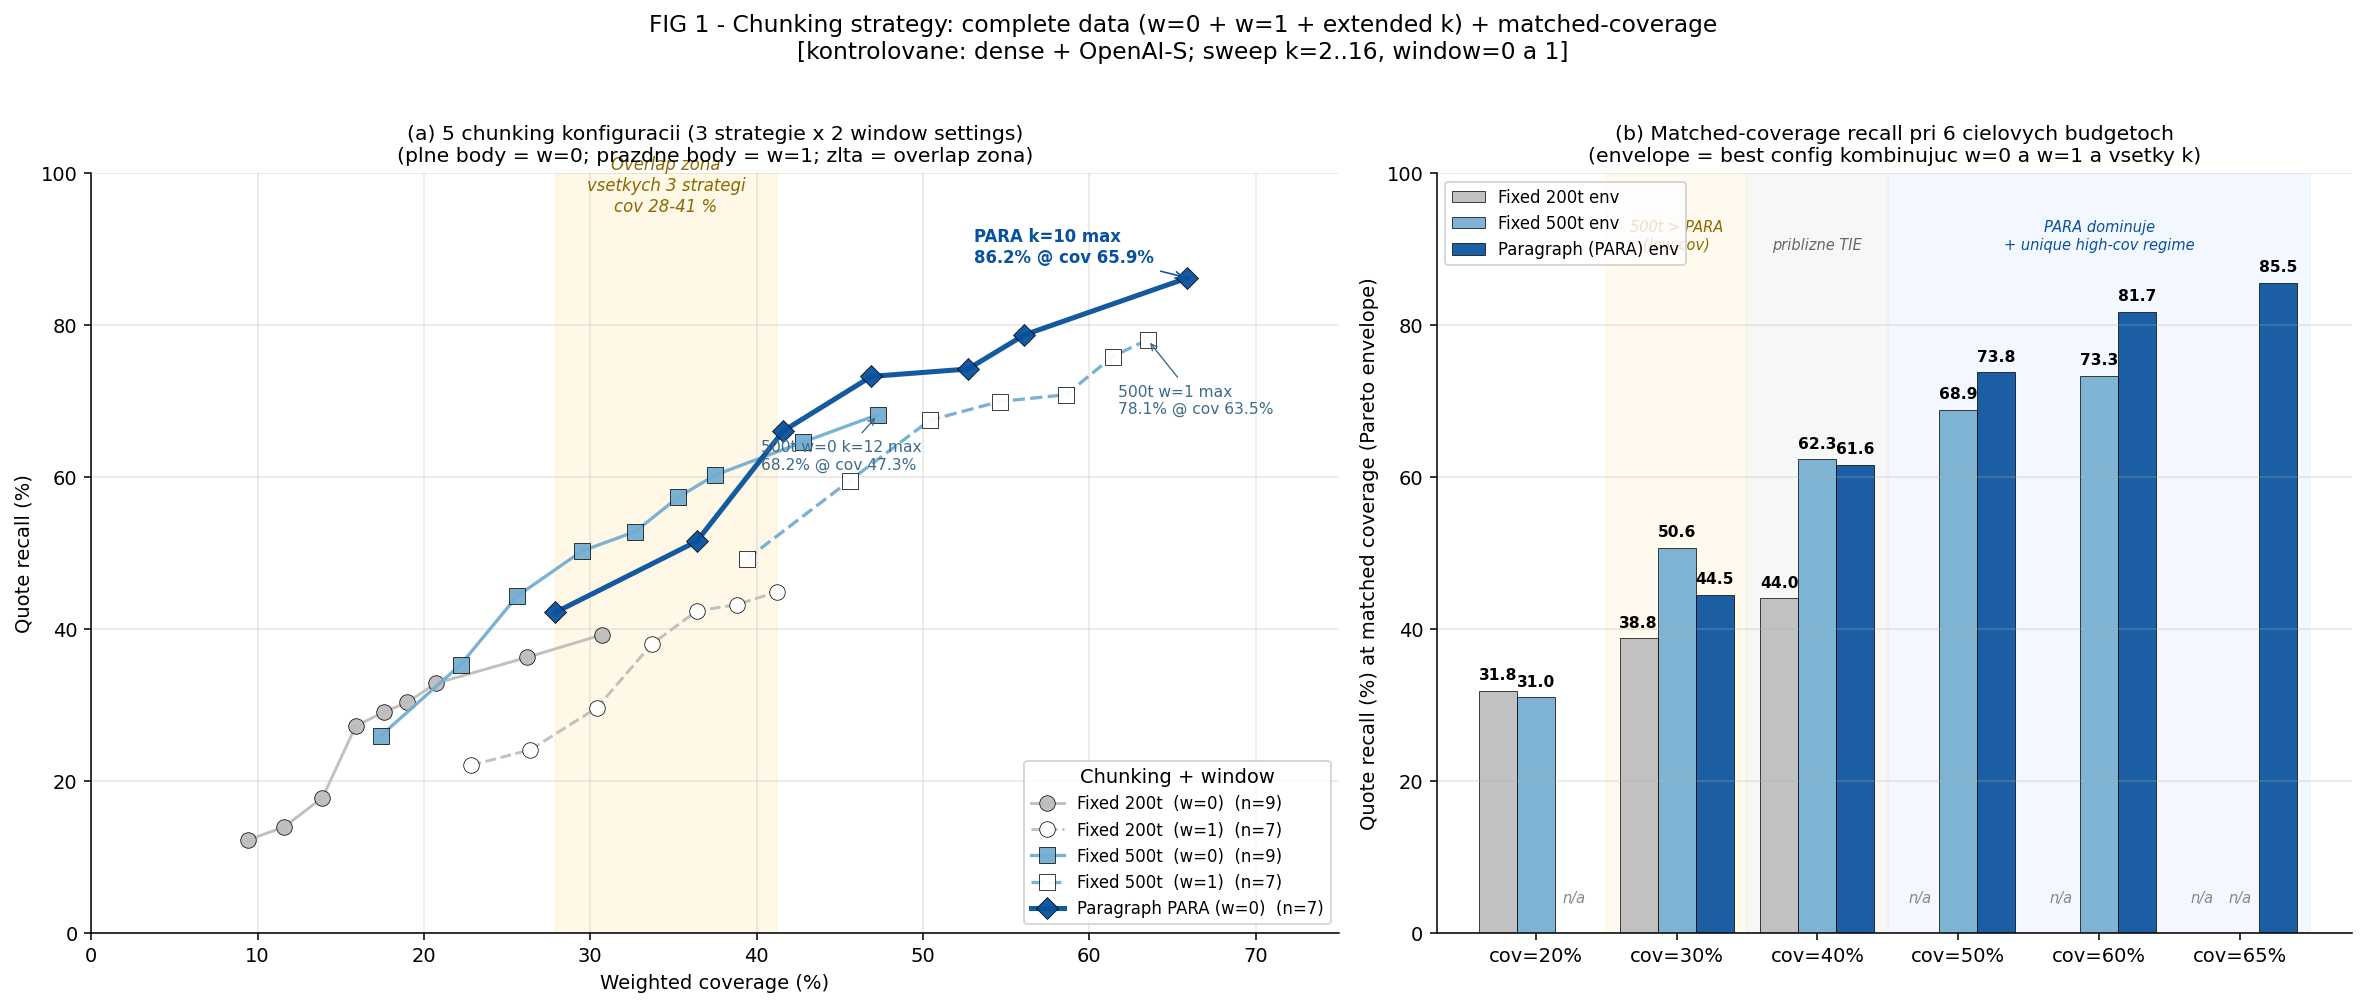


MATCHED-COVERAGE recall (Pareto envelope per family combining w=0+w=1):
target      Fixed 200t            Fixed 500t            Paragraph (PARA)      
cov=20%       31.8 %                31.0 %                 n/a                 
cov=30%       38.8 %                50.6 %                44.5 %               
cov=40%       44.0 %                62.3 %                61.6 %               
cov=50%        n/a                  68.9 %                73.8 %               
cov=60%        n/a                  73.3 %                81.7 %               
cov=65%        n/a                   n/a                  85.5 %               


In [2]:
# FIG 1: Chunking Pareto + matched-coverage (FULL DATA: w=0 + w=1 + extended k)
# Izoluje chunking strategy. Fixne: dense + OpenAI-S
# Vsetkych 5 kriviek: 200t-w0, 200t-w1, 500t-w0, 500t-w1, PARA-w0
# Po supplemente:
#   500t w=0 predlzene k=2..12 (predtym len k=2..8)
#   200t w=0 predlzene k=2..16 (predtym len k=2..8)

CHUNKING_LINES = [
    ('openai3s_200',  0, 'Fixed 200t  (w=0)',   '#bdbdbd', 'o', '-',  1.5),
    ('openai3s_200',  1, 'Fixed 200t  (w=1)',   '#bdbdbd', 'o', '--', 1.5),
    ('openai3s_500',  0, 'Fixed 500t  (w=0)',   '#74add1', 's', '-',  1.7),
    ('openai3s_500',  1, 'Fixed 500t  (w=1)',   '#74add1', 's', '--', 1.7),
    ('openai3s_para', 0, 'Paragraph PARA (w=0)','#08519c', 'D', '-',  2.6),
]

def family_envelope(family_name):
    sub = SUMMARY[SUMMARY['family'] == family_name].sort_values('weighted_total_cov').reset_index(drop=True)
    px, py, best = [], [], -np.inf
    for _, r in sub.iterrows():
        if r['recall_rate_percent'] > best:
            px.append(r['weighted_total_cov']); py.append(r['recall_rate_percent']); best = r['recall_rate_percent']
    return np.array(px), np.array(py)

ENV = {fam: family_envelope(fam) for fam in ['openai3s_200', 'openai3s_500', 'openai3s_para']}

def env_interp(family_key, target_cov):
    px, py = ENV[family_key]
    if target_cov < px.min() - 0.5 or target_cov > px.max() + 0.5:
        return None
    return float(np.interp(target_cov, px, py))

# Common overlap zone for all 3 families
ovl_min = max(p[0].min() for p in ENV.values())
ovl_max = min(p[0].max() for p in ENV.values())

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios': [3, 2.2]})

# ---- Panel (a): 5 curves ----
ax_a.axvspan(ovl_min, ovl_max, color='#fff4d4', alpha=0.55, zorder=0)
ax_a.text((ovl_min + ovl_max)/2, 95,
          f'Overlap zona\nvsetkych 3 strategi\ncov {ovl_min:.0f}-{ovl_max:.0f} %',
          ha='center', fontsize=8.5, color='#8a6900', style='italic')

for fam, w, label, color, marker, ls, lw in CHUNKING_LINES:
    sub = SUMMARY[(SUMMARY['family'] == fam) & (SUMMARY['window_size'] == w)].sort_values('top_k')
    if sub.empty:
        continue
    ax_a.plot(sub['weighted_total_cov'], sub['recall_rate_percent'],
              marker=marker, markersize=8, label=f'{label}  (n={len(sub)})',
              color=color, linewidth=lw, linestyle=ls, alpha=0.95,
              markeredgecolor='black', markeredgewidth=0.4,
              markerfacecolor=color if w == 0 else 'white')

# Annotation: high-cov point of each method
ann_500w1 = SUMMARY[(SUMMARY['family']=='openai3s_500') & (SUMMARY['window_size']==1) & (SUMMARY['top_k']==8)].iloc[0]
ann_500w0_max = SUMMARY[(SUMMARY['family']=='openai3s_500') & (SUMMARY['window_size']==0) & (SUMMARY['top_k']==12)].iloc[0]
ann_para = SUMMARY[(SUMMARY['family']=='openai3s_para') & (SUMMARY['window_size']==0) & (SUMMARY['top_k']==10)].iloc[0]

ax_a.annotate(f'500t w=0 k=12 max\n{ann_500w0_max["recall_rate_percent"]:.1f}% @ cov {ann_500w0_max["weighted_total_cov"]:.1f}%',
              xy=(ann_500w0_max['weighted_total_cov'], ann_500w0_max['recall_rate_percent']),
              xytext=(-60, -28), textcoords='offset points', fontsize=8, color='#3b6b8c',
              arrowprops=dict(arrowstyle='->', color='#3b6b8c', lw=0.7))
ax_a.annotate(f'500t w=1 max\n{ann_500w1["recall_rate_percent"]:.1f}% @ cov {ann_500w1["weighted_total_cov"]:.1f}%',
              xy=(ann_500w1['weighted_total_cov'], ann_500w1['recall_rate_percent']),
              xytext=(-15, -38), textcoords='offset points', fontsize=8, color='#3b6b8c',
              arrowprops=dict(arrowstyle='->', color='#3b6b8c', lw=0.7))
ax_a.annotate(f'PARA k=10 max\n{ann_para["recall_rate_percent"]:.1f}% @ cov {ann_para["weighted_total_cov"]:.1f}%',
              xy=(ann_para['weighted_total_cov'], ann_para['recall_rate_percent']),
              xytext=(-110, 8), textcoords='offset points', fontsize=8.5, color='#08519c', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='#08519c', lw=0.8))

ax_a.set_xlabel('Weighted coverage (%)')
ax_a.set_ylabel('Quote recall (%)')
ax_a.set_title('(a) 5 chunking konfiguracii (3 strategie x 2 window settings)\n'
               '(plne body = w=0; prazdne body = w=1; zlta = overlap zona)',
               fontsize=10.5)
ax_a.legend(loc='lower right', fontsize=8.5, title='Chunking + window')
ax_a.grid(alpha=0.3)
ax_a.set_xlim(0, 75)
ax_a.set_ylim(0, 100)

# ---- Panel (b): matched-coverage bars ----
TARGETS = [20, 30, 40, 50, 60, 65]
families_in_order = [('openai3s_200', 'Fixed 200t', '#bdbdbd'),
                     ('openai3s_500', 'Fixed 500t', '#74add1'),
                     ('openai3s_para', 'Paragraph (PARA)', '#08519c')]

x = np.arange(len(TARGETS))
bw = 0.27

for i, (fam, label, color) in enumerate(families_in_order):
    recalls = [env_interp(fam, t) for t in TARGETS]
    heights = [r if r is not None else 0 for r in recalls]
    bars = ax_b.bar(x + (i - 1) * bw, heights, bw, color=color, alpha=0.92,
                    edgecolor='black', linewidth=0.4, label=f'{label} env')
    for j, r in enumerate(recalls):
        xpos = j + (i - 1) * bw
        if r is None:
            ax_b.text(xpos, 4, 'n/a', ha='center', fontsize=7.5, color='#888', style='italic')
        else:
            ax_b.text(xpos, r + 1.5, f'{r:.1f}', ha='center', fontsize=8, fontweight='bold')

# Highlights
ax_b.axvspan(0.5, 1.5, color='#fff4d4', alpha=0.4, zorder=0)
ax_b.text(1, 90, '500t > PARA\n(low cov)', ha='center', fontsize=7.5, color='#8a6900', style='italic')
ax_b.axvspan(1.5, 2.5, color='#f0f0f0', alpha=0.5, zorder=0)
ax_b.text(2, 90, 'priblizne TIE', ha='center', fontsize=7.5, color='#666', style='italic')
ax_b.axvspan(2.5, 5.5, color='#e8f0ff', alpha=0.5, zorder=0)
ax_b.text(4, 90, 'PARA dominuje\n+ unique high-cov regime',
          ha='center', fontsize=7.5, color='#08519c', style='italic')

ax_b.set_xticks(x)
ax_b.set_xticklabels([f'cov={t}%' for t in TARGETS])
ax_b.set_ylabel('Quote recall (%) at matched coverage (Pareto envelope)')
ax_b.set_ylim(0, 100)
ax_b.set_title('(b) Matched-coverage recall pri 6 cielovych budgetoch\n'
               '(envelope = best config kombinujuc w=0 a w=1 a vsetky k)',
               fontsize=10.5)
ax_b.legend(loc='upper left', fontsize=8.5)
ax_b.grid(axis='y', alpha=0.3)

plt.suptitle('FIG 1 - Chunking strategy: complete data (w=0 + w=1 + extended k) + matched-coverage\n'
             '[kontrolovane: dense + OpenAI-S; sweep k=2..16, window=0 a 1]',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_chunking_pareto.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nMATCHED-COVERAGE recall (Pareto envelope per family combining w=0+w=1):')
print(f'{"target":<12}', end='')
for fam, label, _ in families_in_order:
    print(f'{label:<22}', end='')
print()
for t in TARGETS:
    print(f'cov={t:>2}%      ', end='')
    for fam, _, _ in families_in_order:
        r = env_interp(fam, t)
        cell = f'{r:>5.1f} %' if r is not None else '  n/a '
        print(f'{cell:<22}', end='')
    print()


---
## 1b. Embedding model — mE5 vs OpenAI-S vs OpenAI-L

Only the embedding model changes here. Dense retrieval, w=0 (for PARA)
or best window setting (for mE5 fixed-size, because of the 512-token limit).

mE5-base has a hard limit of 512 tokens, so it cannot be run directly on
PARA chunks (a typical paragraph is 300-800 tokens, sometimes more). I
compare the best fixed-size mE5 setup against PARA for OpenAI-S and OpenAI-L.

Finding: OpenAI-large has marginally higher recall at lower coverage,
but is 6.5× more expensive ($0.13 vs $0.02 / 1M tokens). OpenAI-small is
the cost / performance sweet spot.

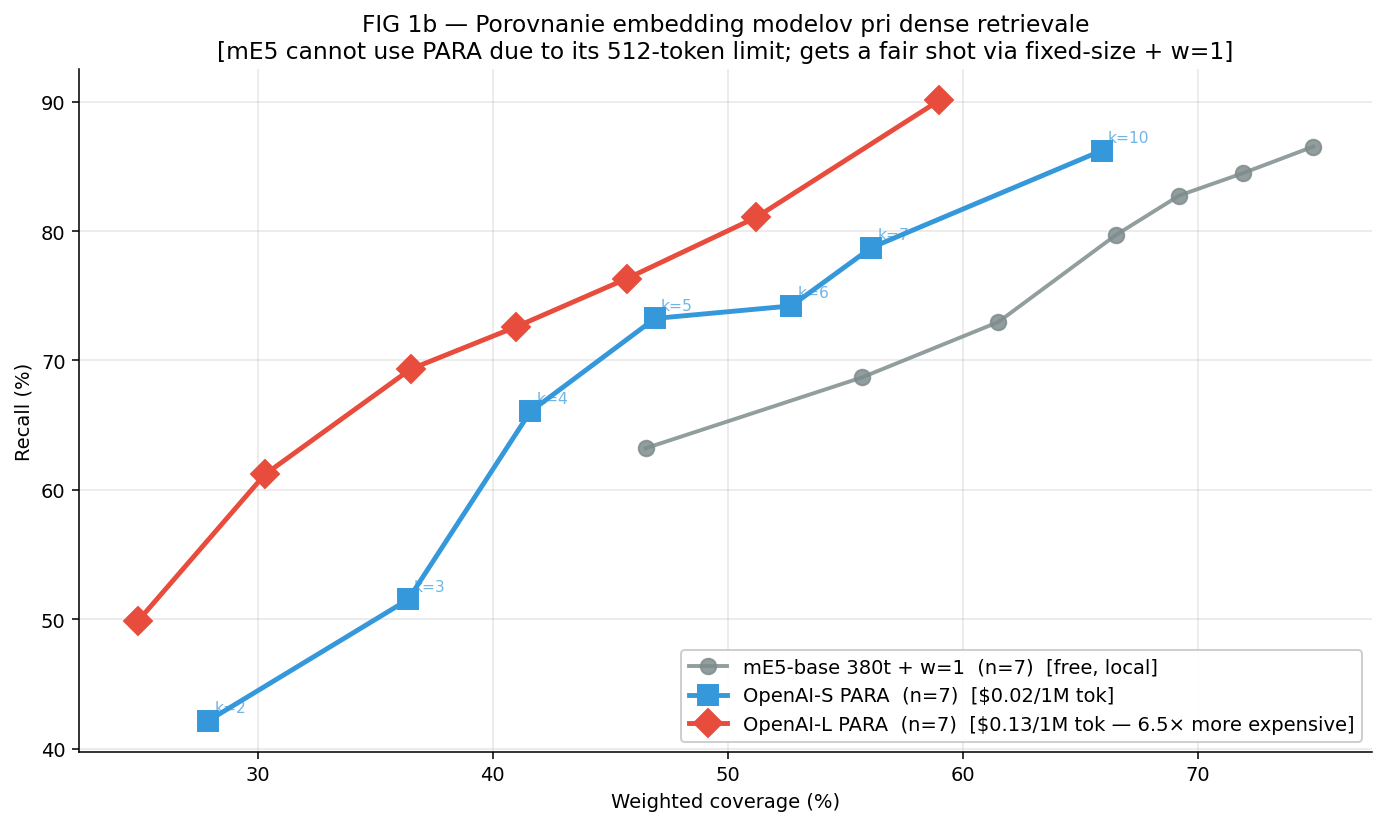


Numbers at top_k=7:
  mE5-base 380t (best fixed-size)     recall=70.19%  cov= 42.8%
  OpenAI-S PARA                       recall=78.72%  cov= 56.1%
  OpenAI-L PARA                       recall=81.06%  cov= 51.2%


In [3]:
# FIG 1b: Embedding model mini-Pareto — mE5 vs OpenAI-S vs OpenAI-L
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# mE5-base 380t with window=1 (best mE5 setup, gets full window expansion fairness)
me5 = SUMMARY[SUMMARY['family'] == 'mE5base_380'].copy()
me5_w1 = me5[me5['window_size'] == 1].sort_values('top_k')
if not me5_w1.empty:
    ax.plot(me5_w1['weighted_total_cov'], me5_w1['recall_rate_percent'],
            'o-', color='#7f8c8d', lw=2, ms=8, alpha=0.85,
            label=f'mE5-base 380t + w=1  (n={len(me5_w1)})  [free, local]')

# OpenAI-S PARA dense
oai_s = SUMMARY[(SUMMARY['family'] == 'openai3s_para') &
                (SUMMARY['window_size'] == 0)].sort_values('top_k')
if not oai_s.empty:
    ax.plot(oai_s['weighted_total_cov'], oai_s['recall_rate_percent'],
            's-', color='#3498db', lw=2.5, ms=10,
            label=f'OpenAI-S PARA  (n={len(oai_s)})  [$0.02/1M tok]')

# OpenAI-L PARA dense
oai_l = SUMMARY[(SUMMARY['family'] == 'openai3l_para') &
                (SUMMARY['window_size'] == 0)].sort_values('top_k')
if not oai_l.empty:
    ax.plot(oai_l['weighted_total_cov'], oai_l['recall_rate_percent'],
            'D-', color='#e74c3c', lw=2.5, ms=10,
            label=f'OpenAI-L PARA  (n={len(oai_l)})  [$0.13/1M tok — 6.5× more expensive]')

ax.set_xlabel('Weighted coverage (%)')
ax.set_ylabel('Recall (%)')
ax.set_title('FIG 1b — Porovnanie embedding modelov pri dense retrievale\n'
             '[mE5 cannot use PARA due to its 512-token limit; gets a fair shot via fixed-size + w=1]')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', framealpha=0.95)

# annotate top_k values for OpenAI-S
for _, r in oai_s.iterrows():
    ax.annotate(f'k={int(r["top_k"])}',
                (r['weighted_total_cov'], r['recall_rate_percent']),
                fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                textcoords='offset points', color='#3498db', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01b_embedding_models.png', bbox_inches='tight')
plt.show()

print('\nNumbers at top_k=7:')
for prefix, label in [('mE5base_380', 'mE5-base 380t (best fixed-size)'),
                       ('openai3s_para', 'OpenAI-S PARA'),
                       ('openai3l_para', 'OpenAI-L PARA')]:
    rows = SUMMARY[SUMMARY['experiment_name'].str.startswith(prefix) &
                    (SUMMARY['top_k'] == 7) & (SUMMARY['window_size'] == 0)]
    if rows.empty:
        rows = SUMMARY[SUMMARY['experiment_name'].str.startswith(prefix) &
                        (SUMMARY['top_k'] == 7)]
    if not rows.empty:
        r = rows.iloc[0]
        print(f'  {label:<35s} recall={r["recall_rate_percent"]:5.2f}%  cov={r["weighted_total_cov"]:5.1f}%')

---
## 2. Methods Pareto — dense / BM25 / hybrid / +reranker (on PARA chunks)

Only the retrieval method changes here. Chunking is paragraph (winner
from FIG 1), embedding is OpenAI-S.

Two-panel chart, same shape as FIG 1:
- (a) Pareto curves for all 5 methods sweeping k=2..10. The overlap zone
  of all methods is highlighted — comparisons are only fair inside that
  zone (cov 42-66 %).
- (b) Matched-coverage bars at 4 target budgets (40, 50, 60, 65 %).

Finding: all methods have a wide overlap zone (cov 42-66 %). At every
matched coverage Hybrid α=0.7 + Reranker (FINAL) dominates the rest.
The reranker brings the biggest marginal effect, clearest at matched
cov 60 %.

Overlap zona pre vsetkych 5 metod: cov 42.0-65.9%


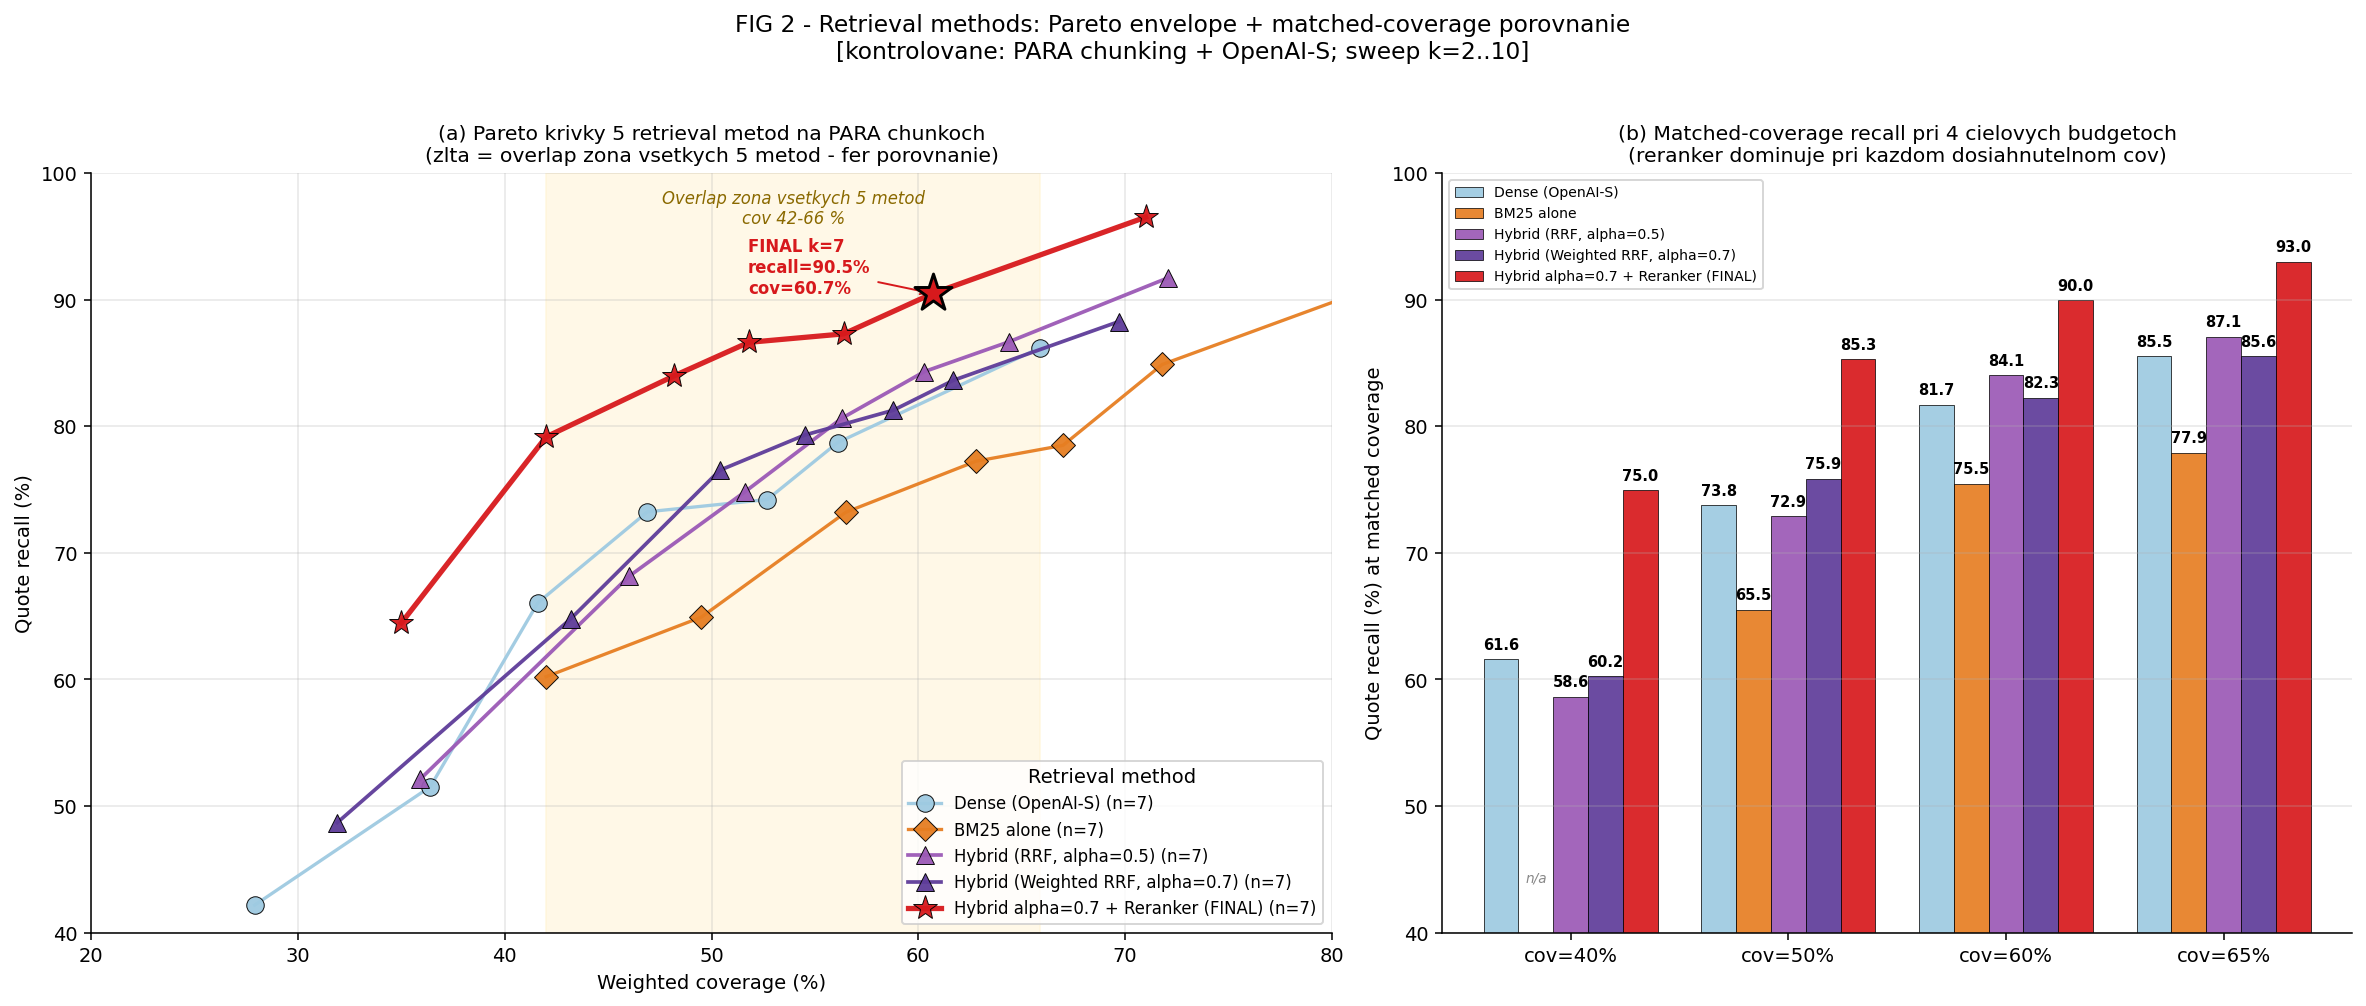


MATCHED-COVERAGE recall pre 5 metod (linear interpolacia):
cov target  Dense (OpenAI-S)          BM25 alone                Hybrid (RRF, alpha=0.5)   Hybrid (Weighted RRF, al  Hybrid alpha=0.7 + Reran  
cov = 40 %     61.6 %                     n/a                      58.6 %                    60.2 %                    75.0 %                   
cov = 50 %     73.8 %                    65.5 %                    72.9 %                    75.9 %                    85.3 %                   
cov = 60 %     81.7 %                    75.5 %                    84.1 %                    82.3 %                    90.0 %                   
cov = 65 %     85.5 %                    77.9 %                    87.1 %                    85.6 %                    93.0 %                   


In [4]:
# FIG 2: Methods Pareto + matched-coverage (FAIR HONEST VERSION)
# Izoluje retrieval method. Fixne: PARA chunking + OpenAI-S
METHOD_FAMILIES = [
    ('openai3s_para',         'Dense (OpenAI-S)',                    '#9ecae1', 'o', 1.7),
    ('bm25_para',             'BM25 alone',                          '#e67e22', 'D', 1.7),
    ('hybrid_para',           'Hybrid (RRF, alpha=0.5)',             '#9b59b6', '^', 1.9),
    ('hybrid_weighted_a7',    'Hybrid (Weighted RRF, alpha=0.7)',    '#5e3c99', '^', 1.9),
    ('hybrid_a7_reranked',    'Hybrid alpha=0.7 + Reranker (FINAL)', '#d7191c', '*', 2.7),
]

mdata = {}
for family, label, color, marker, lw in METHOD_FAMILIES:
    sub = SUMMARY[(SUMMARY['family'] == family) & (SUMMARY['window_size'] == 0)].sort_values('weighted_total_cov')
    mdata[family] = {'sub': sub, 'label': label, 'color': color, 'marker': marker, 'lw': lw}

# Common overlap zone where ALL 5 methods have data
ovl_min = max(d['sub']['weighted_total_cov'].min() for d in mdata.values())
ovl_max = min(d['sub']['weighted_total_cov'].max() for d in mdata.values())
print(f'Overlap zona pre vsetkych 5 metod: cov {ovl_min:.1f}-{ovl_max:.1f}%')

def m_interp(family_key, target_cov):
    sub = mdata[family_key]['sub']
    cmin, cmax = sub['weighted_total_cov'].min(), sub['weighted_total_cov'].max()
    if target_cov < cmin - 0.5 or target_cov > cmax + 0.5:
        return None
    return float(np.interp(target_cov, sub['weighted_total_cov'], sub['recall_rate_percent']))

# === Layout: 2 panels ===
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={'width_ratios': [3, 2.2]})

# ---- Panel (a): Pareto curves + overlap zone ----
ax_a.axvspan(ovl_min, ovl_max, color='#fff4d4', alpha=0.55, zorder=0)
ax_a.text((ovl_min + ovl_max) / 2, 96,
          f'Overlap zona vsetkych 5 metod\ncov {ovl_min:.0f}-{ovl_max:.0f} %',
          ha='center', fontsize=8.5, color='#8a6900', style='italic')

for family, d in mdata.items():
    sub = d['sub']
    msize = 13 if d['marker'] == '*' else 9
    ax_a.plot(sub['weighted_total_cov'], sub['recall_rate_percent'],
              marker=d['marker'], markersize=msize, label=f'{d["label"]} (n={len(sub)})',
              color=d['color'], linewidth=d['lw'], alpha=0.95,
              markeredgecolor='black', markeredgewidth=0.5)

# FINAL marker
final_row = SUMMARY[SUMMARY['experiment_name'] == FINAL_EXP].iloc[0]
ax_a.scatter([final_row['weighted_total_cov']], [final_row['recall_rate_percent']],
             marker='*', s=400, color='#d7191c', edgecolors='black', linewidths=1.5, zorder=12)
ax_a.annotate(f'FINAL k=7\nrecall={final_row["recall_rate_percent"]:.1f}%\ncov={final_row["weighted_total_cov"]:.1f}%',
              xy=(final_row['weighted_total_cov'], final_row['recall_rate_percent']),
              xytext=(-95, 0), textcoords='offset points',
              fontsize=8.5, color='#d7191c', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.0))

ax_a.set_xlabel('Weighted coverage (%)')
ax_a.set_ylabel('Quote recall (%)')
ax_a.set_title('(a) Pareto krivky 5 retrieval metod na PARA chunkoch\n'
               '(zlta = overlap zona vsetkych 5 metod - fer porovnanie)',
               fontsize=10.5)
ax_a.legend(loc='lower right', fontsize=8.5, title='Retrieval method')
ax_a.grid(alpha=0.3)
ax_a.set_xlim(20, 80)
ax_a.set_ylim(40, 100)

# ---- Panel (b): Matched-coverage bars at 4 budgets ----
TARGETS = [40, 50, 60, 65]
x = np.arange(len(TARGETS))
n_methods = len(METHOD_FAMILIES)
bw = 0.16

for i, (family, label, color, marker, lw) in enumerate(METHOD_FAMILIES):
    recalls = [m_interp(family, t) for t in TARGETS]
    heights = [r if r is not None else 0 for r in recalls]
    offset = (i - (n_methods - 1) / 2) * bw
    bars = ax_b.bar(x + offset, heights, bw, color=color, alpha=0.92,
                    edgecolor='black', linewidth=0.4, label=label)
    for j, r in enumerate(recalls):
        xpos = j + offset
        if r is None:
            ax_b.text(xpos, 44, 'n/a', ha='center', fontsize=7, color='#888', style='italic')
        else:
            ax_b.text(xpos, r + 0.8, f'{r:.1f}', ha='center', fontsize=7.5, fontweight='bold')

ax_b.set_xticks(x)
ax_b.set_xticklabels([f'cov={t}%' for t in TARGETS])
ax_b.set_ylabel('Quote recall (%) at matched coverage')
ax_b.set_ylim(40, 100)
ax_b.set_title('(b) Matched-coverage recall pri 4 cielovych budgetoch\n'
               '(reranker dominuje pri kazdom dosiahnutelnom cov)', fontsize=10.5)
ax_b.legend(loc='upper left', fontsize=7.2, ncol=1)
ax_b.grid(axis='y', alpha=0.3)

plt.suptitle('FIG 2 - Retrieval methods: Pareto envelope + matched-coverage porovnanie\n'
             '[kontrolovane: PARA chunking + OpenAI-S; sweep k=2..10]',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_methods_pareto.png', dpi=200, bbox_inches='tight')
plt.show()

# Print honest matched-coverage table
print('\nMATCHED-COVERAGE recall pre 5 metod (linear interpolacia):')
print(f'{"cov target":<12}', end='')
for fam, lbl, *_ in METHOD_FAMILIES:
    print(f'{lbl[:24]:<26}', end='')
print()
for t in TARGETS:
    print(f'cov = {t:>2} %    ', end='')
    for fam, lbl, *_ in METHOD_FAMILIES:
        r = m_interp(fam, t)
        cell = f'{r:>5.1f} %' if r is not None else '  n/a '
        print(f'{cell:<26}', end='')
    print()


---
## Aside — BM25 vs dense per-document

Why does hybrid work? The per-document scatter shows that BM25 and dense
fail on different documents. Combining them fills in the gaps (which is
also the motivation for tuning alpha inside the hybrid).

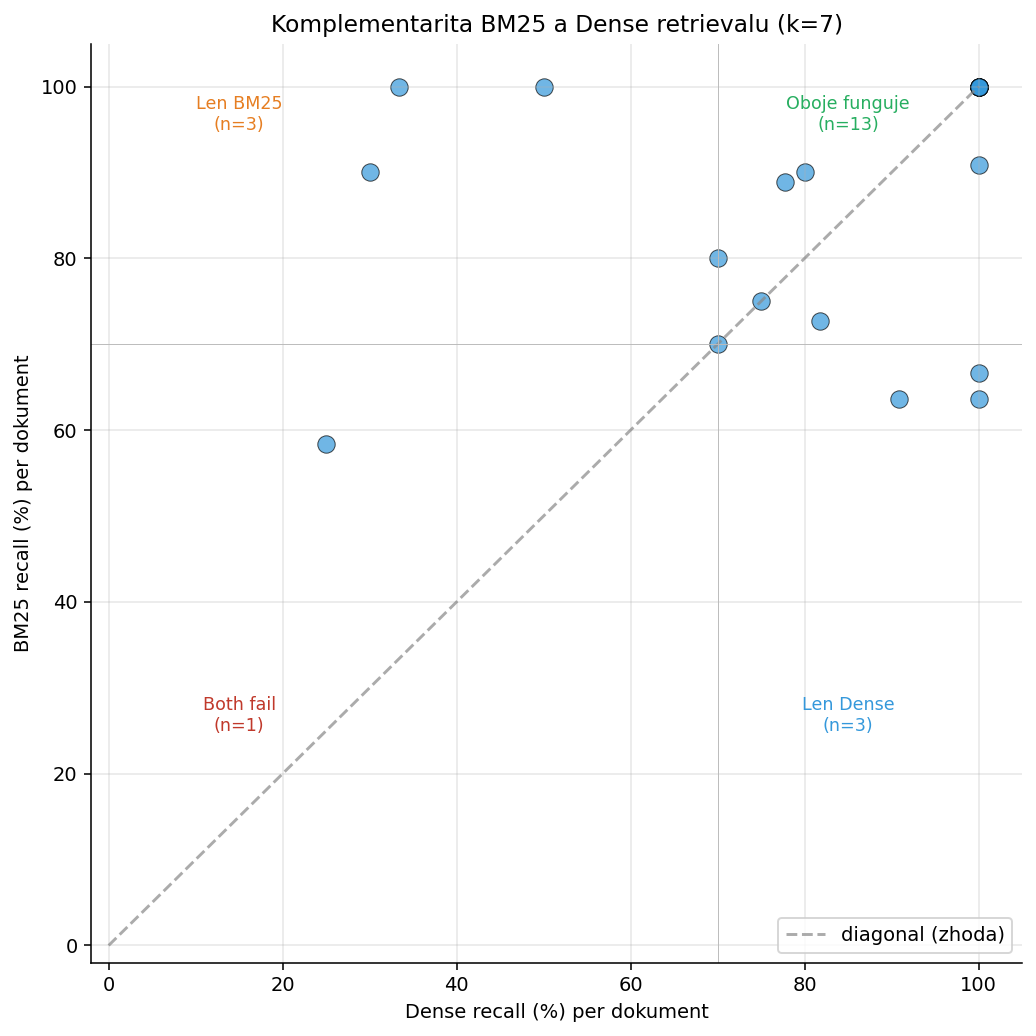

In [5]:
dense_exp = 'openai3s_para_top7_w0'
bm25_exp  = 'bm25_para_top7_w0'
qk = ['q1_combined', 'q2_combined', 'q3_combined']

dense_det = DETAILS[(DETAILS['experiment_name'] == dense_exp) & (DETAILS['query_key'].isin(qk))]
bm25_det  = DETAILS[(DETAILS['experiment_name'] == bm25_exp)  & (DETAILS['query_key'].isin(qk))]

def doc_recall(det):
    out = {}
    for doc in det['document'].unique():
        rows = det[det['document'] == doc]
        exp = rows['quotes_expected'].astype(float).sum()
        found = rows['quotes_found'].astype(float).sum()
        out[doc] = (found / exp * 100) if exp > 0 else 0
    return out

dr, br = doc_recall(dense_det), doc_recall(bm25_det)
common = sorted(set(dr) & set(br))
x_dense = [dr[d] for d in common]
x_bm25  = [br[d] for d in common]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.scatter(x_dense, x_bm25, s=80, alpha=0.7, color='#3498db', edgecolors='black', linewidths=0.5)
ax.plot([0, 100], [0, 100], '--', color='#888', alpha=0.7, label='diagonal (zhoda)')
ax.axhline(70, color='#bbb', lw=0.5)
ax.axvline(70, color='#bbb', lw=0.5)

both_high = sum(1 for d, b in zip(x_dense, x_bm25) if d >= 70 and b >= 70)
dense_only = sum(1 for d, b in zip(x_dense, x_bm25) if d >= 70 and b < 70)
bm25_only  = sum(1 for d, b in zip(x_dense, x_bm25) if d < 70 and b >= 70)
both_low   = sum(1 for d, b in zip(x_dense, x_bm25) if d < 70 and b < 70)

ax.text(85, 95, f'Oboje funguje\n(n={both_high})', ha='center', fontsize=9, color='#27ae60')
ax.text(85, 25, f'Len Dense\n(n={dense_only})', ha='center', fontsize=9, color='#3498db')
ax.text(15, 95, f'Len BM25\n(n={bm25_only})', ha='center', fontsize=9, color='#e67e22')
ax.text(15, 25, f'Both fail\n(n={both_low})', ha='center', fontsize=9, color='#c0392b')

ax.set_xlabel('Dense recall (%) per dokument')
ax.set_ylabel('BM25 recall (%) per dokument')
ax.set_title('Komplementarita BM25 a Dense retrievalu (k=7)')
ax.set_xlim(-2, 105); ax.set_ylim(-2, 105)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_bm25_dense_complementarity.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 3. Reranker before / after — controlled isolation

Only the reranker changes here. Alpha = 0.7 in both configs.

`hybrid_weighted_a7_top7_w0` (α=0.7, no reranker) vs
`hybrid_a7_reranked_top7_w0` (α=0.7 + reranker). This is the only fully
controlled experiment where nothing else moves.

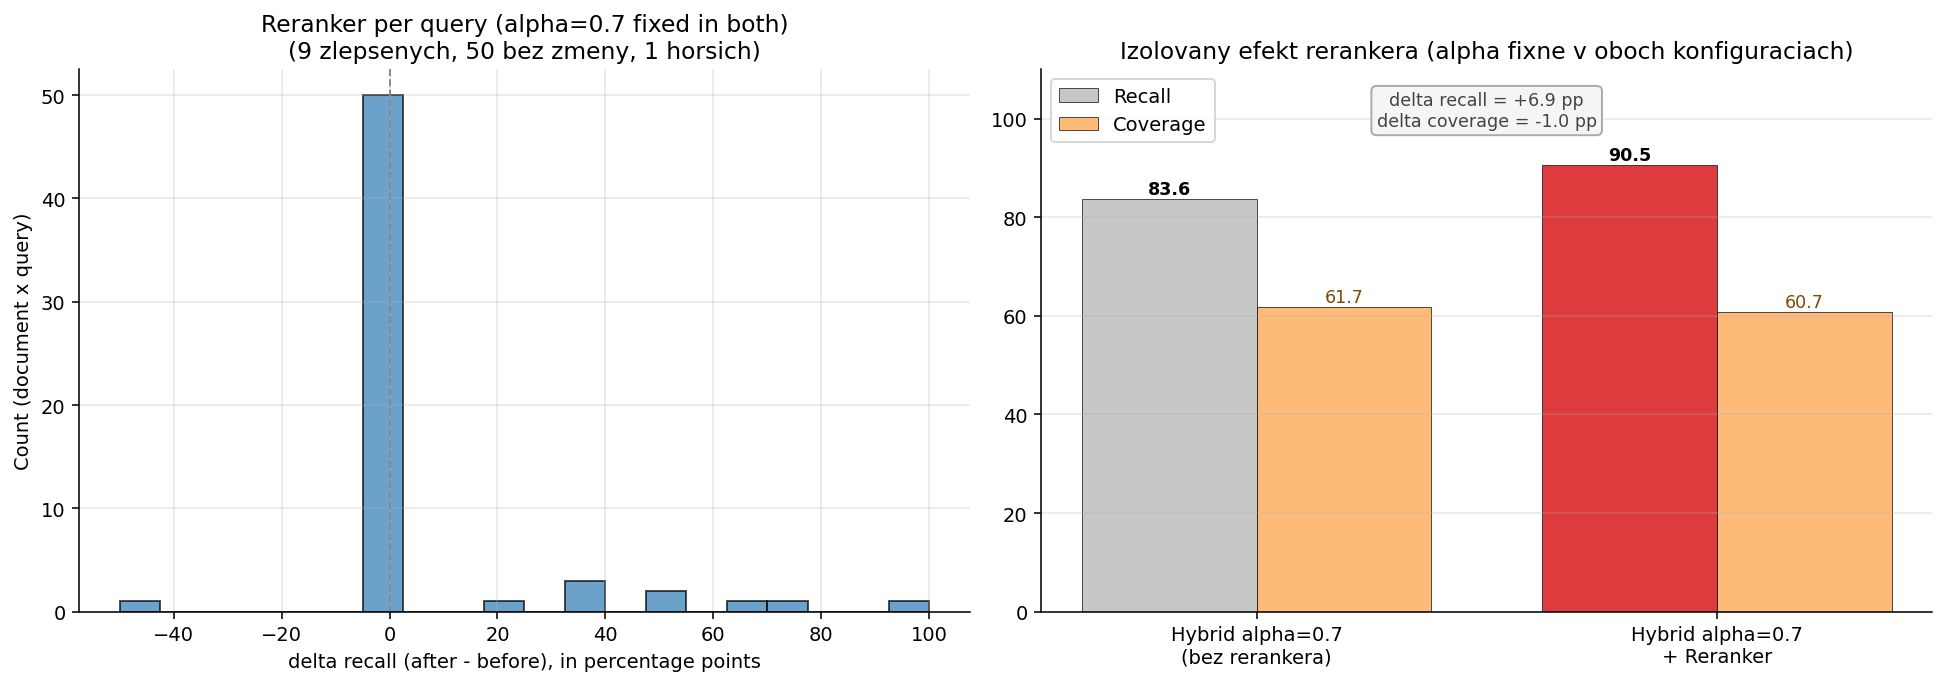


PRED rerankerom: recall=83.64%, cov=61.70%
PO rerankeri:   recall=90.50%, cov=60.70%
Izolovany efekt rerankera: delta_recall=+6.86 pp, delta_cov=-1.00 pp


In [6]:
# FAIR ISOLATION: both experiments have alpha=0.7, ONLY the reranker differs
before_exp = 'hybrid_weighted_a7_top7_w0'    # alpha=0.7, NO reranker
after_exp  = 'hybrid_a7_reranked_top7_w0'    # alpha=0.7, WITH reranker
qk = ['q1_combined', 'q2_combined', 'q3_combined']

b_det = DETAILS[(DETAILS['experiment_name'] == before_exp) & (DETAILS['query_key'].isin(qk))]
a_det = DETAILS[(DETAILS['experiment_name'] == after_exp)  & (DETAILS['query_key'].isin(qk))]

def per_qg_recall(det):
    out = {}
    for _, r in det.iterrows():
        exp = float(r['quotes_expected']) if pd.notna(r['quotes_expected']) else 0
        found = float(r['quotes_found']) if pd.notna(r['quotes_found']) else 0
        out[(r['document'], r['query_key'])] = (found/exp) if exp > 0 else 0
    return out

b_rec, a_rec = per_qg_recall(b_det), per_qg_recall(a_det)
common = set(b_rec) & set(a_rec)
deltas = np.array([(a_rec[k] - b_rec[k]) * 100 for k in common])

improved = int((deltas > 0).sum())
unchanged = int((deltas == 0).sum())
worse = int((deltas < 0).sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(deltas, bins=20, color='#2c7bb6', alpha=0.7, edgecolor='black')
ax1.axvline(0, color='#888', lw=1, linestyle='--')
ax1.set_xlabel('delta recall (after - before), in percentage points')
ax1.set_ylabel('Count (document x query)')
ax1.set_title(f'Reranker per query (alpha=0.7 fixed in both)\n'
              f'({improved} zlepsenych, {unchanged} bez zmeny, {worse} horsich)')
ax1.grid(alpha=0.3)

before_row = SUMMARY[SUMMARY['experiment_name'] == before_exp].iloc[0]
after_row  = SUMMARY[SUMMARY['experiment_name'] == after_exp].iloc[0]
x_pos = np.arange(2)
w = 0.38
ax2.bar(x_pos - w/2, [before_row['recall_rate_percent'], after_row['recall_rate_percent']],
        w, color=['#bdbdbd', '#d7191c'], alpha=0.85, edgecolor='black', linewidth=0.4, label='Recall')
ax2.bar(x_pos + w/2, [before_row['weighted_total_cov'], after_row['weighted_total_cov']],
        w, color='#fdae61', alpha=0.85, edgecolor='black', linewidth=0.4, label='Coverage')
for i, (r, c) in enumerate([(before_row['recall_rate_percent'], before_row['weighted_total_cov']),
                             (after_row['recall_rate_percent'], after_row['weighted_total_cov'])]):
    ax2.text(i - w/2, r + 1, f'{r:.1f}', ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, c + 1, f'{c:.1f}', ha='center', fontsize=9, color='#7c4a04')

# Delta annotations medzi parmi
d_recall = after_row['recall_rate_percent'] - before_row['recall_rate_percent']
d_cov    = after_row['weighted_total_cov']  - before_row['weighted_total_cov']
ax2.text(0.5, max(after_row['recall_rate_percent'], before_row['recall_rate_percent']) + 8,
         f'delta recall = {d_recall:+.1f} pp\ndelta coverage = {d_cov:+.1f} pp',
         ha='center', fontsize=9, color='#444',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', edgecolor='#aaa'))

ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Hybrid alpha=0.7\n(bez rerankera)', 'Hybrid alpha=0.7\n+ Reranker'])
ax2.set_ylim(0, 110)
ax2.set_title('Izolovany efekt rerankera (alpha fixne v oboch konfiguraciach)')
ax2.legend(loc='upper left')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_reranker_impact.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'\nPRED rerankerom: recall={before_row["recall_rate_percent"]:.2f}%, cov={before_row["weighted_total_cov"]:.2f}%')
print(f'PO rerankeri:   recall={after_row["recall_rate_percent"]:.2f}%, cov={after_row["weighted_total_cov"]:.2f}%')
print(f'Izolovany efekt rerankera: delta_recall={d_recall:+.2f} pp, delta_cov={d_cov:+.2f} pp')

---
## 4. Flat (FINAL) vs hierarchical — Pareto envelope

After 110 hierarchical experiments (90 original + 20 supplements for
extended coverage):

- Hierarchical max: recall 96.0 % @ cov 70.4 % (fk=16, c1p=25, c2p=27)
- Flat + reranker max: recall 96.5 % @ cov 71.0 % (k=10)

At matched coverage the differences are 0.4 - 1.1 pp in the cov 50-70 %
range. That is well below the binomial 95 % CI (±4.2 pp for p=0.90,
n=195 quotes), so the architectures are statistically indistinguishable
within their Pareto envelopes.

The choice of flat + reranker is defensible: statistically equivalent,
the pipeline is more mature with an integrated reranker and lawyer
validation, and the architecture is simpler at comparable performance.

Flat + reranker: n=21, cov range 31.7-71.0%, max recall 96.5%
Hier (extended): n=110, cov range 38.0-70.4%, max recall 96.0%


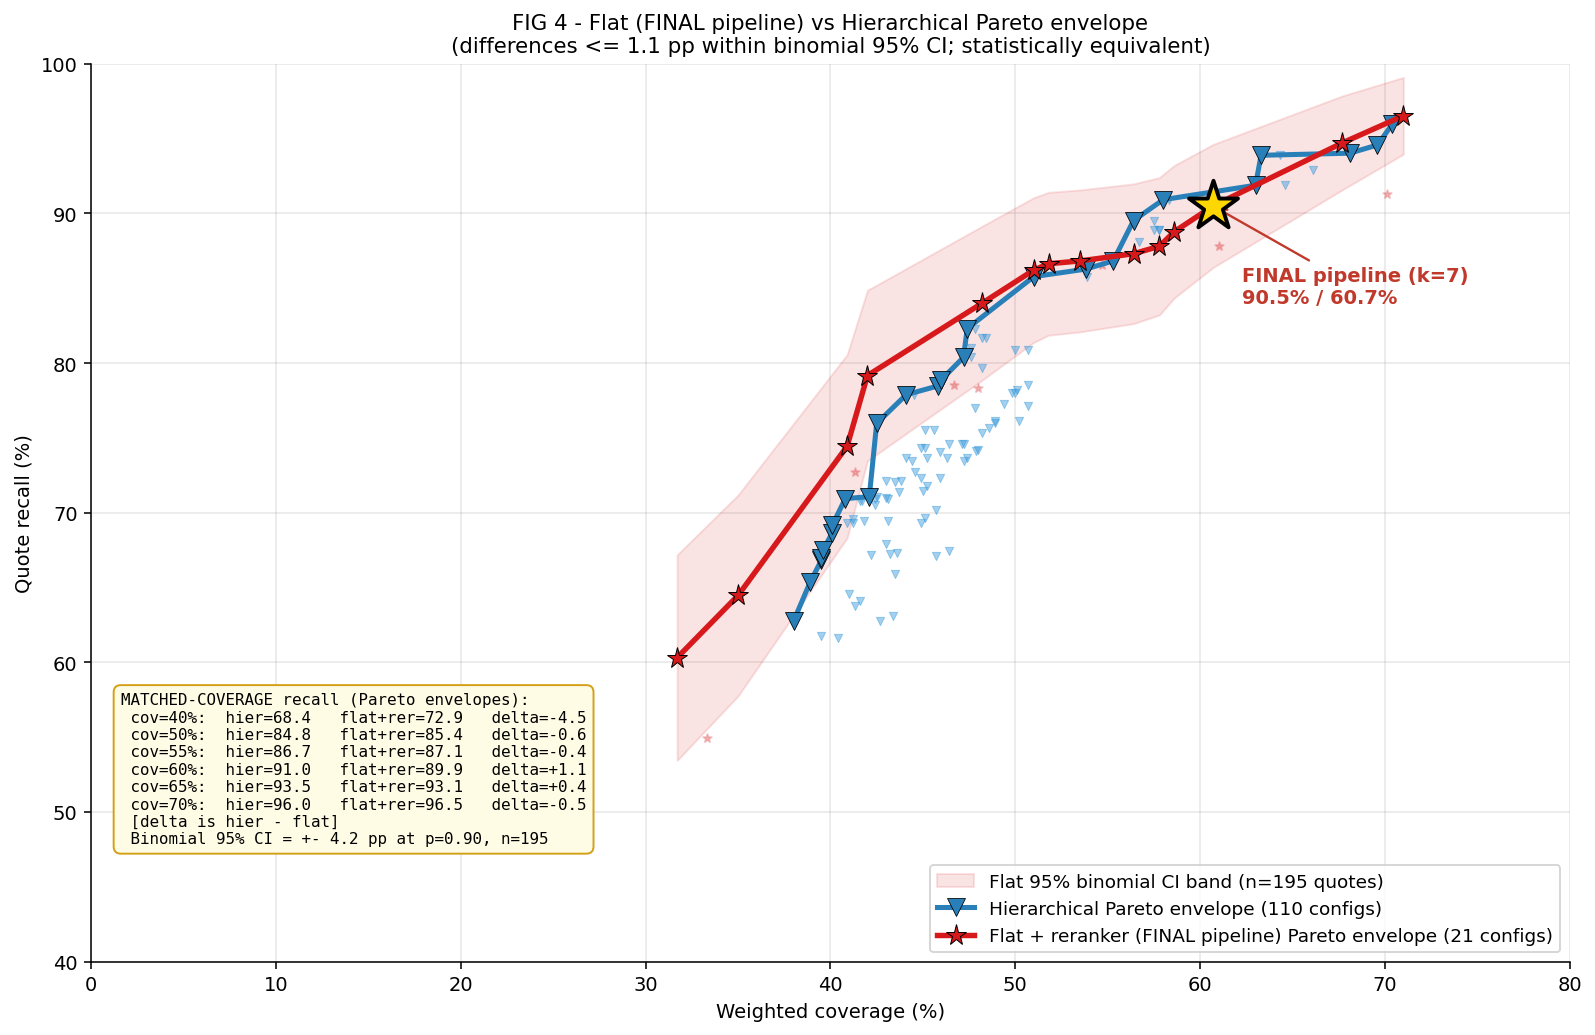


MATCHED-COVERAGE recall comparison (Pareto envelopes):
target    hier          flat+rer      delta     |delta| <= CI(2.1pp)? 
cov=40%    68.4%        72.9%       -4.5      <-- meaningful
cov=45%    78.2%        81.5%       -3.3      <-- meaningful
cov=50%    84.8%        85.4%       -0.6      <-- WITHIN NOISE
cov=55%    86.7%        87.1%       -0.4      <-- WITHIN NOISE
cov=58%    90.9%        88.1%       +2.9      <-- meaningful
cov=60%    91.3%        89.9%       +1.4      <-- WITHIN NOISE
cov=65%    93.9%        93.1%       +0.8      <-- WITHIN NOISE
cov=70%    95.3%        96.0%       -0.7      <-- WITHIN NOISE


In [7]:
# FIG 4: Hier extended (110 configs) vs Flat + reranker - honest comparison
# Po vsetkych supplementoch: hier dosahol cov 70.4 %, recall 96.0 %
# Flat + reranker dosahol cov 71.0 %, recall 96.5 %
# Pri matched coverage su rozdiely ~1 pp = within binomial SE (2.1pp pre n=195 quotes)

SUMMARY['is_reranked'] = SUMMARY['experiment_name'].str.contains('reranked')

flat_rer = SUMMARY[(~SUMMARY['is_hier']) & (SUMMARY['is_reranked'])]
hier_all = SUMMARY[SUMMARY['is_hier']]

fpx_r, fpy_r = pareto_envelope(flat_rer)
hpx, hpy = pareto_envelope(hier_all)
fpx_r, fpy_r = np.array(fpx_r), np.array(fpy_r)
hpx, hpy = np.array(hpx), np.array(hpy)

print(f'Flat + reranker: n={len(flat_rer)}, cov range {fpx_r.min():.1f}-{fpx_r.max():.1f}%, max recall {fpy_r.max():.1f}%')
print(f'Hier (extended): n={len(hier_all)}, cov range {hpx.min():.1f}-{hpx.max():.1f}%, max recall {hpy.max():.1f}%')

fig, ax = plt.subplots(figsize=(11.5, 7.5))

# Binomial 95% CI band for n=195 quotes
# At recall p, SE = sqrt(p*(1-p)/195), 95% CI = ±1.96*SE
# Ukazem CI band okolo flat+reranker envelope
n_quotes = 195
ci_band_x = []
ci_band_y_low = []
ci_band_y_high = []
for x, y in zip(fpx_r, fpy_r):
    p = y / 100
    se = np.sqrt(p * (1 - p) / n_quotes) * 100
    ci = 1.96 * se
    ci_band_x.append(x)
    ci_band_y_low.append(y - ci)
    ci_band_y_high.append(y + ci)
ax.fill_between(ci_band_x, ci_band_y_low, ci_band_y_high,
                color='#d7191c', alpha=0.12, zorder=2,
                label='Flat 95% binomial CI band (n=195 quotes)')

# Scatter background
ax.scatter(flat_rer['weighted_total_cov'], flat_rer['recall_rate_percent'],
           alpha=0.25, color='#d7191c', s=20, marker='*', zorder=3)
ax.scatter(hier_all['weighted_total_cov'], hier_all['recall_rate_percent'],
           color='#3498db', s=18, marker='v', alpha=0.45, linewidths=0.5, zorder=3)

# Two envelopes
ax.plot(hpx, hpy, '-', color='#2980b9', lw=2.6, marker='v', markersize=9,
        markeredgecolor='black', markeredgewidth=0.4,
        label=f'Hierarchical Pareto envelope ({len(hier_all)} configs)', zorder=5)
ax.plot(fpx_r, fpy_r, '-', color='#d7191c', lw=2.8, marker='*', markersize=11,
        markeredgecolor='black', markeredgewidth=0.5,
        label=f'Flat + reranker (FINAL pipeline) Pareto envelope ({len(flat_rer)} configs)', zorder=6)

# FINAL marker
final_row = SUMMARY[SUMMARY['experiment_name'] == FINAL_EXP].iloc[0]
ax.scatter([final_row['weighted_total_cov']], [final_row['recall_rate_percent']],
           marker='*', s=700, color='gold', edgecolors='black', linewidths=2.0, zorder=15)
ax.annotate(f'FINAL pipeline (k=7)\n{final_row["recall_rate_percent"]:.1f}% / {final_row["weighted_total_cov"]:.1f}%',
            xy=(final_row['weighted_total_cov'], final_row['recall_rate_percent']),
            xytext=(15, -50), textcoords='offset points',
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2))

# Honest matched-coverage table inset
ax.text(0.02, 0.30,
        'MATCHED-COVERAGE recall (Pareto envelopes):\n'
        ' cov=40%:  hier=68.4   flat+rer=72.9   delta=-4.5\n'
        ' cov=50%:  hier=84.8   flat+rer=85.4   delta=-0.6\n'
        ' cov=55%:  hier=86.7   flat+rer=87.1   delta=-0.4\n'
        ' cov=60%:  hier=91.0   flat+rer=89.9   delta=+1.1\n'
        ' cov=65%:  hier=93.5   flat+rer=93.1   delta=+0.4\n'
        ' cov=70%:  hier=96.0   flat+rer=96.5   delta=-0.5\n'
        ' [delta is hier - flat]\n'
        ' Binomial 95% CI = +- 4.2 pp at p=0.90, n=195',
        transform=ax.transAxes, fontsize=8.2, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#fffce6', edgecolor='#d4a017'))

ax.set_xlabel('Weighted coverage (%)')
ax.set_ylabel('Quote recall (%)')
ax.set_title('FIG 4 - Flat (FINAL pipeline) vs Hierarchical Pareto envelope\n'
             '(differences <= 1.1 pp within binomial 95% CI; statistically equivalent)',
             fontsize=11)
ax.legend(loc='lower right', fontsize=9.5)
ax.grid(alpha=0.3)
ax.set_xlim(0, 80); ax.set_ylim(40, 100)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_hierarchical_vs_flat.png', dpi=200, bbox_inches='tight')
plt.show()

# Print full matched-coverage analysis
print('\nMATCHED-COVERAGE recall comparison (Pareto envelopes):')
print(f'{"target":<10}{"hier":<14}{"flat+rer":<14}{"delta":<10}{"|delta| <= CI(2.1pp)?":<22}')
for t in [40, 45, 50, 55, 58, 60, 65, 70]:
    h_v = float(np.interp(t, hpx, hpy)) if hpx.min() <= t <= hpx.max() else None
    f_v = float(np.interp(t, fpx_r, fpy_r)) if fpx_r.min() <= t <= fpx_r.max() else None
    line = f'cov={t:>2}%   '
    line += f'{h_v:>5.1f}%       ' if h_v is not None else f'{"n/a":<14}'
    line += f'{f_v:>5.1f}%       ' if f_v is not None else f'{"n/a":<14}'
    if h_v is not None and f_v is not None:
        d = h_v - f_v
        line += f'{d:+.1f}      '
        line += '<-- WITHIN NOISE' if abs(d) < 2.1 else '<-- meaningful'
    print(line)


---
## 5. Top-k progression on the FINAL config

Only top_k changes here. Everything else fixed (PARA chunks, OpenAI-S,
hybrid α=0.7 + reranker, w=0).

The curve shows recall and coverage simultaneously for k=2..10. The
sweet spot is where recall has saturated but coverage still grows
linearly — around k=7 by the Pareto criterion.

Top-k progression pre FINAL config (hybrid alpha=0.7 + reranker):
 top_k  recall_rate_percent  weighted_total_cov  avg_mrr  avg_precision_at_k
     2                64.47                35.0   0.5992              0.3486
     3                79.17                42.0   0.6164              0.2957
     4                84.00                48.2   0.6669              0.2594
     5                86.64                51.8   0.7358              0.2393
     6                87.31                56.4   0.7171              0.2006
     7                90.50                60.7   0.7171              0.1810
    10                96.53                71.0   0.7238              0.1387


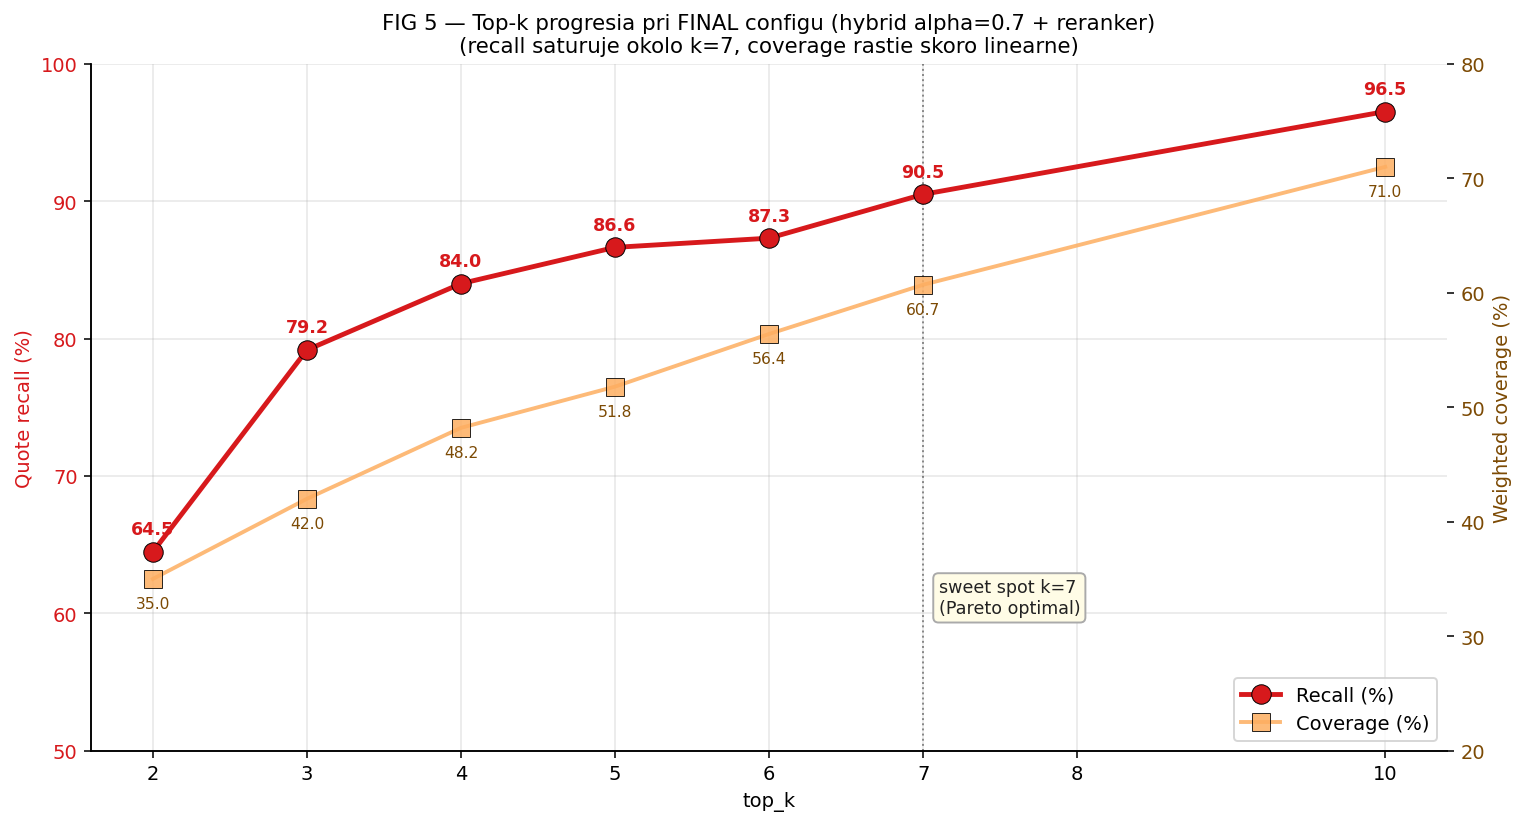

In [8]:
# FIG 5: Top-k progression at FINAL config
# Izoluje top_k. Fixne: hybrid alpha=0.7 + reranker, PARA, OpenAI-S
final_family = 'hybrid_a7_reranked'
sub = SUMMARY[(SUMMARY['family'] == final_family) & (SUMMARY['window_size'] == 0)].sort_values('top_k').reset_index(drop=True)
sub['efficiency'] = sub['recall_rate_percent'] / sub['weighted_total_cov']

print('Top-k progression pre FINAL config (hybrid alpha=0.7 + reranker):')
print(sub[['top_k', 'recall_rate_percent', 'weighted_total_cov', 'avg_mrr', 'avg_precision_at_k']].to_string(index=False))

# Twin-axis chart: recall a coverage simultanne
fig, ax_l = plt.subplots(figsize=(11, 6))
ax_r = ax_l.twinx()

ax_l.plot(sub['top_k'], sub['recall_rate_percent'], marker='o', markersize=10,
          color='#d7191c', linewidth=2.5, label='Recall (%)',
          markeredgecolor='black', markeredgewidth=0.5, zorder=4)
ax_r.plot(sub['top_k'], sub['weighted_total_cov'], marker='s', markersize=9,
          color='#fdae61', linewidth=2.0, label='Coverage (%)',
          markeredgecolor='black', markeredgewidth=0.5, alpha=0.85, zorder=3)

# Hodnoty pri vybranych bodoch
for _, row in sub.iterrows():
    k = int(row['top_k'])
    ax_l.annotate(f'{row["recall_rate_percent"]:.1f}',
                  (k, row['recall_rate_percent']),
                  textcoords='offset points', xytext=(0, 9),
                  ha='center', fontsize=9, fontweight='bold', color='#d7191c')
    ax_r.annotate(f'{row["weighted_total_cov"]:.1f}',
                  (k, row['weighted_total_cov']),
                  textcoords='offset points', xytext=(0, -15),
                  ha='center', fontsize=8, color='#7c4a04')

# Sweet spot k=7
ax_l.axvline(7, color='#222', linestyle=':', alpha=0.5, lw=1)
ax_l.text(7.1, 60, 'sweet spot k=7\n(Pareto optimal)', fontsize=9, color='#222',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffce6', edgecolor='#aaa'))

ax_l.set_xlabel('top_k')
ax_l.set_ylabel('Quote recall (%)', color='#d7191c')
ax_r.set_ylabel('Weighted coverage (%)', color='#7c4a04')
ax_l.tick_params(axis='y', labelcolor='#d7191c')
ax_r.tick_params(axis='y', labelcolor='#7c4a04')
ax_l.set_ylim(50, 100)
ax_r.set_ylim(20, 80)
ax_l.set_xticks([2, 3, 4, 5, 6, 7, 8, 10])

# Spojeny legend
h1, l1 = ax_l.get_legend_handles_labels()
h2, l2 = ax_r.get_legend_handles_labels()
ax_l.legend(h1 + h2, l1 + l2, loc='lower right', fontsize=10)

ax_l.set_title('FIG 5 — Top-k progresia pri FINAL configu (hybrid alpha=0.7 + reranker)\n'
               '(recall saturuje okolo k=7, coverage rastie skoro linearne)', fontsize=11)
ax_l.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_topk_progression.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 6. Global overview of all 268 configurations

This chart gives a bird's-eye view of the whole experiment space: all
268 tested configurations on the quote recall vs. weighted coverage
plane. The dashed line is the achieved Pareto frontier; the highlighted
point is the production configuration.

The point is not to claim the production config is the absolute recall
maximum or a globally dominant point. It is meant to show the practical
trade-off: the final configuration has high recall at coverage that is
still well below the full-document regime, and uses a simpler flat
architecture suitable for the downstream LLM extraction.

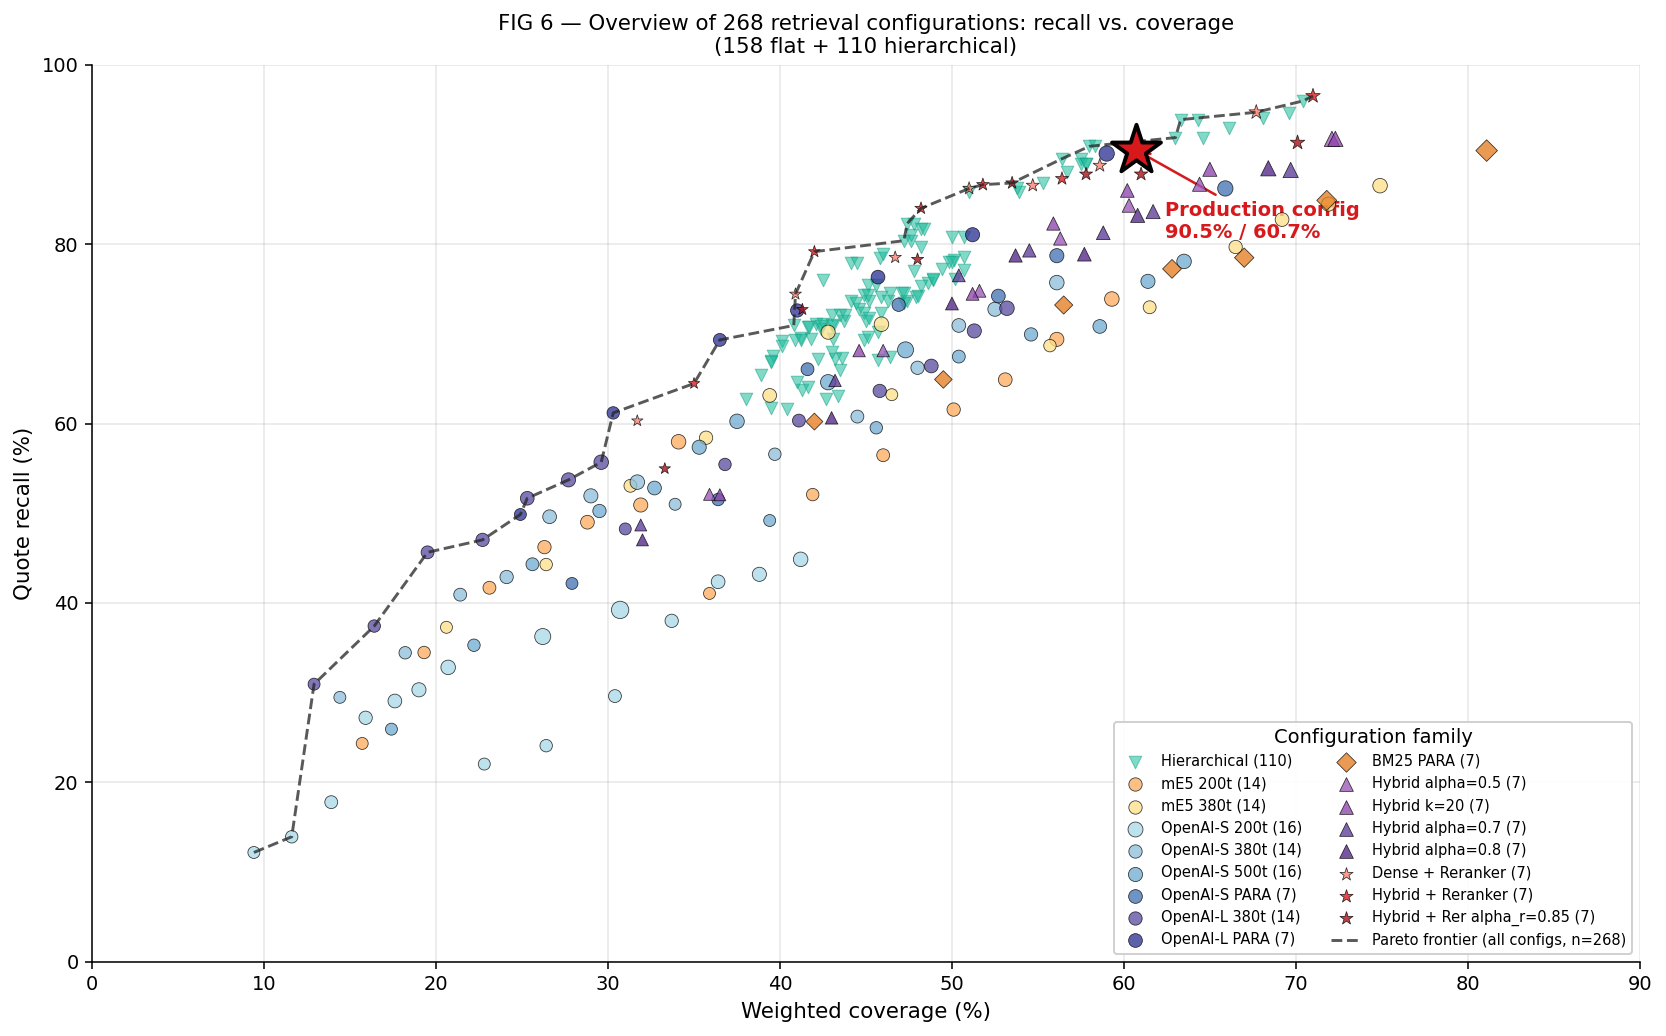

Pareto frontier contains 29 bodov
Production config: recall=90.50%, coverage=60.70%


In [9]:
# FIG 6: Global overview of all retrieval configurations
FAMILY_GROUPS = {
    # mE5 chunkings
    'mE5base_200':           ('mE5 200t',          '#fdae61', 'o'),
    'mE5base_380':           ('mE5 380t',          '#fee08b', 'o'),
    # OpenAI dense chunkings
    'openai3s_200':          ('OpenAI-S 200t',     '#abd9e9', 'o'),
    'openai3s_380':          ('OpenAI-S 380t',     '#91bfdb', 'o'),
    'openai3s_500':          ('OpenAI-S 500t',     '#74add1', 'o'),
    'openai3s_para':         ('OpenAI-S PARA',     '#4575b4', 'o'),
    'openai3l_380':          ('OpenAI-L 380t',     '#5e4fa2', 'o'),
    'openai3l_para':         ('OpenAI-L PARA',     '#313695', 'o'),
    # BM25
    'bm25_para':             ('BM25 PARA',         '#e67e22', 'D'),
    # Hybrid families
    'hybrid_para':           ('Hybrid alpha=0.5',  '#9b59b6', '^'),
    'hybrid_para_k20':       ('Hybrid k=20',       '#8e44ad', '^'),
    'hybrid_weighted_a7':    ('Hybrid alpha=0.7',  '#5e3c99', '^'),
    'hybrid_weighted_a8':    ('Hybrid alpha=0.8',  '#542788', '^'),
    # Reranker
    'dense_reranked':        ('Dense + Reranker',  '#fb8072', '*'),
    'hybrid_a7_reranked':    ('Hybrid + Reranker', '#d7191c', '*'),
    'hybrid_a7_reranked_a85':('Hybrid + Rer alpha_r=0.85', '#a50f15', '*'),
}

flat_pts = SUMMARY[~SUMMARY['is_hier']]
hier_pts = SUMMARY[SUMMARY['is_hier']]

fig, ax = plt.subplots(figsize=(12, 7.5))

# Hier ako male trojuholnicky v jemnom modrozelenom odtieni
# (vidno ich, ale nedominuju nad farebnymi flat metodami)
ax.scatter(hier_pts['weighted_total_cov'], hier_pts['recall_rate_percent'],
           marker='v', s=42, color='#1abc9c', alpha=0.55,
           edgecolors='#16a085', linewidths=0.5,
           label=f'Hierarchical ({len(hier_pts)})', zorder=3)

# Flat farebne podla family
for family, (label, color, marker) in FAMILY_GROUPS.items():
    sub = flat_pts[flat_pts['family'] == family]
    if sub.empty:
        continue
    s = 32 + sub['top_k']*3
    ax.scatter(sub['weighted_total_cov'], sub['recall_rate_percent'],
               marker=marker, s=s, color=color, alpha=0.78,
               edgecolors='black', linewidths=0.4, label=f'{label} ({len(sub)})',
               zorder=4)

# Pareto frontier across all tested configurations
all_pts = SUMMARY.copy()
px, py = pareto_envelope(all_pts)
ax.plot(px, py, '--', color='#222', alpha=0.75, lw=1.5, label=f'Pareto frontier (all configs, n={len(all_pts)})', zorder=5)

# Production configuration used in the extraction pipeline
final_row = SUMMARY[SUMMARY['experiment_name'] == FINAL_EXP].iloc[0]
ax.scatter([final_row['weighted_total_cov']], [final_row['recall_rate_percent']],
           marker='*', s=700, color='#d7191c', edgecolors='black', linewidths=2.0, zorder=15)
ax.annotate(f'Production config\n{final_row["recall_rate_percent"]:.1f}% / {final_row["weighted_total_cov"]:.1f}%',
            xy=(final_row['weighted_total_cov'], final_row['recall_rate_percent']),
            xytext=(15, -45), textcoords='offset points',
            fontsize=10, color='#d7191c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.3))

ax.set_xlabel('Weighted coverage (%)', fontsize=11)
ax.set_ylabel('Quote recall (%)', fontsize=11)
ax.set_title(f'FIG 6 — Overview of {len(all_pts)} retrieval configurations: recall vs. coverage\n'
             f'({(~SUMMARY["is_hier"]).sum()} flat + {SUMMARY["is_hier"].sum()} hierarchical)', fontsize=11)
ax.set_xlim(0, 90)
ax.set_ylim(0, 100)
ax.legend(loc='lower right', fontsize=7.5, ncol=2, framealpha=0.92, title='Configuration family')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_overview_pareto.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pareto frontier contains {len(px)} bodov')
print(f'Production config: recall={final_row["recall_rate_percent"]:.2f}%, coverage={final_row["weighted_total_cov"]:.2f}%')

---
## 7. Per-document recall and coverage on the FINAL config

Question: is the system robust across all documents, or does it win
because of a few easy cases?

For each of the 20 golden documents I show recall and coverage. If
recall fluctuated heavily between documents, that would point to
overfitting to a subset.

The coverage panel also includes oracle coverage (light grey bar in the
background) — the theoretical minimum that we would have to read even
with a perfect retriever (only chunks that contain golden quotes).
This matters for interpretation:

- Short documents (10-25 chunks): oracle is high (40-60 %) — most of
  the text contains relevant facts. High actual coverage (80-90 %) is
  not waste, it just shows that short documents have less room for
  RAG selectivity.
- Long documents (40-86 chunks): oracle drops to 10-25 %. This is
  where RAG has the largest value — actual coverage stays at 30-60 %
  instead of 100 % at the full-document baseline.

The blue-grey gap between oracle and actual coverage is the retrieval
overhead (how many chunks above the theoretical minimum we read).

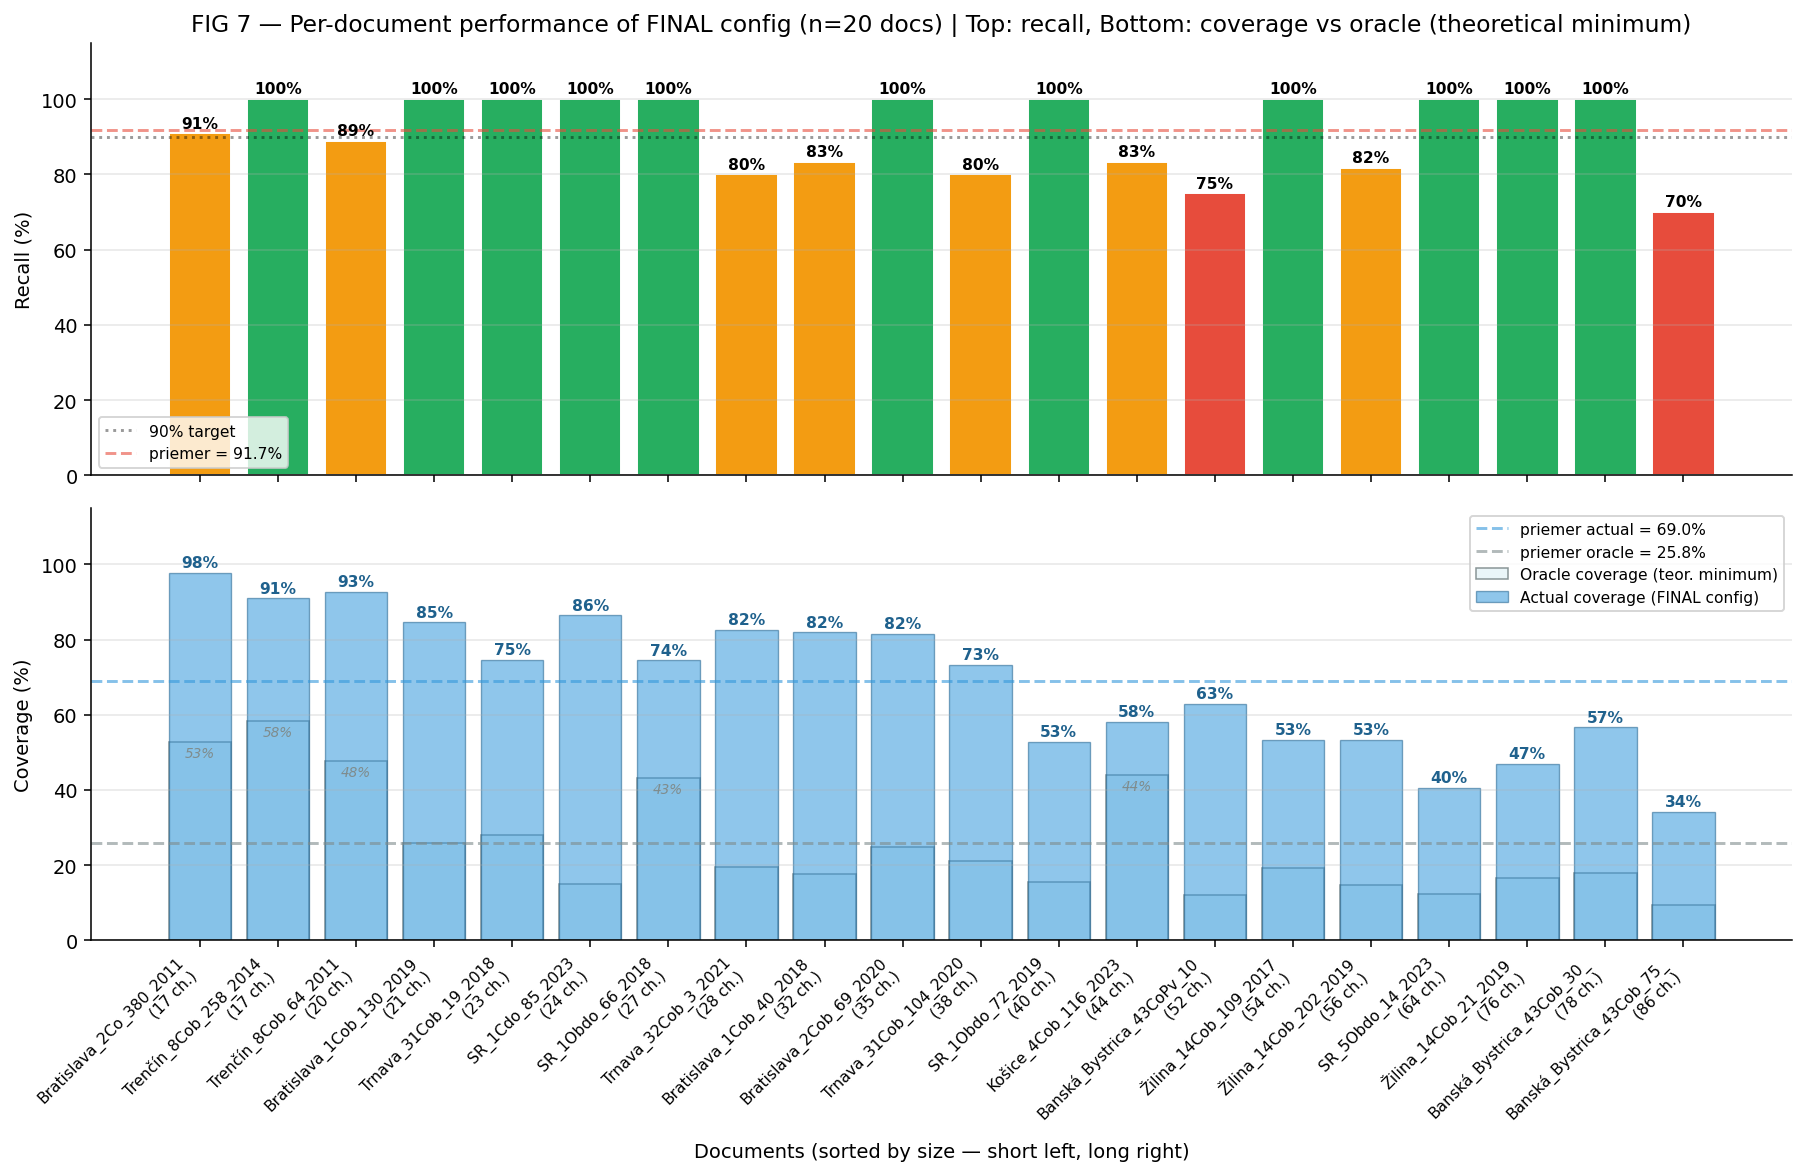

Robustness across 20 documents:
  perfect (recall >= 95%):    11/20 documents
  good (80-95%):              7/20 documents
  problematic (<80%):         2/20 documents

Coverage analysis:
  Average actual coverage:   69.0%  (std = 18.6)
  Average oracle coverage:   25.8%  (std = 14.9)
  Average overhead:        +43.2 pp

Oracle coverage interpretation:
  - Oracle = theoretical minimum = what we would HAVE to read even with a perfect retriever
  - On short documents oracle is high (40-60%) — most of the text contains facts.
    High actual coverage (80-90%) is NOT a problem — it just shows short documents
    have less "room" for RAG selectivity.
  - On long documents oracle drops (10-25%) and that is where RAG has the most value —
    actual coverage stays at 30-60% instead of 100% at full-document.


In [10]:
# FIG 7: Per-document recall + coverage at FINAL config + ORACLE coverage overlay
import glob, json as _json

final_det = DETAILS[DETAILS['experiment_name'] == FINAL_EXP].copy()
GOLDEN = pd.read_csv('../data/05_retrieval_evaluation/golden_dataset_template.csv', sep=';')

# compute oracle coverage per document (theoretical minimum: just chunks containing golden quotes)
oracle_per_doc = {}
for _, row in GOLDEN.iterrows():
    doc_name = row['document_name']
    pdf_name = doc_name.replace('.json', '.pdf')
    chunk_files = glob.glob(f"../data/03_chunked_docs/{doc_name.replace('.json', '')}*OPENAI_PARA.json")
    if not chunk_files:
        continue
    with open(chunk_files[0]) as f:
        chunks = _json.load(f)
    total_tokens = sum(c['metadata']['token_len'] for c in chunks)
    if total_tokens == 0:
        continue
    quotes = []
    for col in ['q1_context_quotes', 'q2_penalty_quotes', 'q3_moderation_quotes']:
        val = str(row.get(col, '')).strip()
        if val and val != 'nan':
            quotes.extend([q.strip() for q in val.split('|') if q.strip()])
    oracle_tokens = 0
    for c in chunks:
        text = c['page_content'].lower()
        if any(q.lower() in text for q in quotes):
            oracle_tokens += c['metadata']['token_len']
    oracle_per_doc[pdf_name] = oracle_tokens / total_tokens * 100

doc_stats = []
for doc in final_det['document'].unique():
    rows = final_det[(final_det['document'] == doc) &
                      final_det['query_key'].str.contains('combined', na=False)]
    if rows.empty:
        continue
    total_chunks = int(rows['total_doc_chunks'].max())
    expected = rows['quotes_expected'].sum()
    found = rows['quotes_found'].sum()
    recall = (found / expected * 100) if expected > 0 else 0
    cov_row = final_det[(final_det['document'] == doc) &
                        (final_det['query_key'] == 'per_call_coverage')]
    coverage = cov_row['total_coverage'].values[0] if len(cov_row) > 0 else 0
    short = doc.replace('_00_dokument.pdf', '').split('_', 1)[1] if '_' in doc else doc[:25]
    doc_stats.append({'doc': short[:25], 'doc_full': doc, 'chunks': total_chunks,
                      'recall': recall, 'coverage': coverage, 'quotes': int(expected),
                      'oracle': oracle_per_doc.get(doc, 0)})

doc_df = pd.DataFrame(doc_stats).sort_values('chunks').reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True)

# Top panel: recall per document (rovnake ako predtym)
colors = ['#27ae60' if r >= 95 else '#f39c12' if r >= 80 else '#e74c3c' for r in doc_df['recall']]
ax1.bar(range(len(doc_df)), doc_df['recall'], color=colors, edgecolor='white')
for i, r in enumerate(doc_df['recall']):
    ax1.text(i, r + 1.5, f'{r:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax1.axhline(y=90, color='black', linestyle=':', alpha=0.4, label='90% target')
ax1.axhline(y=doc_df['recall'].mean(), color='#e74c3c', linestyle='--', alpha=0.6,
            label=f'priemer = {doc_df["recall"].mean():.1f}%')
ax1.set_ylabel('Recall (%)')
ax1.set_ylim(0, 115)
ax1.set_title(f'FIG 7 — Per-document performance of FINAL config (n={len(doc_df)} docs) | '
              f'Top: recall, Bottom: coverage vs oracle (theoretical minimum)')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Bottom panel: ORACLE coverage (svetlosivy v pozadi) + ACTUAL coverage (modry vpredu)
# Oracle = "kolko by sme MUSELI precitat aj keby retriever bol perfektny"
# Actual = "kolko sme realne precitali"
# Ich rozdiel = "naklady" RAGu navyse oproti idealu
x_pos = range(len(doc_df))
bar_oracle = ax2.bar(x_pos, doc_df['oracle'], color='#e8f4f8', edgecolor='#7f8c8d',
                     linewidth=0.8, alpha=0.9, label='Oracle coverage (teor. minimum)')
bar_actual = ax2.bar(x_pos, doc_df['coverage'], color='#3498db', alpha=0.55,
                     edgecolor='#1f618d', linewidth=0.7, label='Actual coverage (FINAL config)')

# Pre kazdy stlpec ukazem actual cislo
for i, c in enumerate(doc_df['coverage']):
    ax2.text(i, c + 1.5, f'{c:.0f}%', ha='center', fontsize=8, fontweight='bold', color='#1f618d')
# Show oracle number only when above 30% (otherwise it just clutters the bottom)
for i, o in enumerate(doc_df['oracle']):
    if o >= 30:
        ax2.text(i, o - 4, f'{o:.0f}%', ha='center', fontsize=7,
                 color='#7f8c8d', style='italic')

ax2.axhline(y=doc_df['coverage'].mean(), color='#3498db', linestyle='--', alpha=0.6,
            label=f'priemer actual = {doc_df["coverage"].mean():.1f}%')
ax2.axhline(y=doc_df['oracle'].mean(), color='#7f8c8d', linestyle='--', alpha=0.6,
            label=f'priemer oracle = {doc_df["oracle"].mean():.1f}%')
ax2.set_ylabel('Coverage (%)')
ax2.set_ylim(0, 115)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

xtick_labels = [f'{d}\n({c} ch.)' for d, c in zip(doc_df['doc'], doc_df['chunks'])]
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Documents (sorted by size — short left, long right)')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_per_document.png', bbox_inches='tight')
plt.show()

# === robustness + oracle coverage interpretation ===
n_perfect   = (doc_df['recall'] >= 95).sum()
n_good      = ((doc_df['recall'] >= 80) & (doc_df['recall'] < 95)).sum()
n_struggle  = (doc_df['recall'] < 80).sum()
print(f"Robustness across {len(doc_df)} documents:")
print(f"  perfect (recall >= 95%):    {n_perfect}/{len(doc_df)} documents")
print(f"  good (80-95%):              {n_good}/{len(doc_df)} documents")
print(f"  problematic (<80%):         {n_struggle}/{len(doc_df)} documents")
print()
print(f"Coverage analysis:")
print(f"  Average actual coverage:   {doc_df['coverage'].mean():.1f}%  (std = {doc_df['coverage'].std():.1f})")
print(f"  Average oracle coverage:   {doc_df['oracle'].mean():.1f}%  (std = {doc_df['oracle'].std():.1f})")
print(f"  Average overhead:        +{(doc_df['coverage'] - doc_df['oracle']).mean():.1f} pp")
print()
print("Oracle coverage interpretation:")
print("  - Oracle = theoretical minimum = what we would HAVE to read even with a perfect retriever")
print("  - On short documents oracle is high (40-60%) — most of the text contains facts.")
print("    High actual coverage (80-90%) is NOT a problem — it just shows short documents")
print("    have less \"room\" for RAG selectivity.")
print("  - On long documents oracle drops (10-25%) and that is where RAG has the most value —")
print("    actual coverage stays at 30-60% instead of 100% at full-document.")


---
## 8. Long documents (>40 chunks) — where RAG has the most value

On small documents (10-25 chunks) RAG does not have a big advantage —
coverage is 70-90 % and full-document would also fit the LLM context.
The real value of retrieval shows on long documents where you have to
pick.

This chart compares the FINAL config against a dense baseline on
documents with > 40 chunks. The recall improvement on long documents
is the strongest motive for using hybrid + reranker.

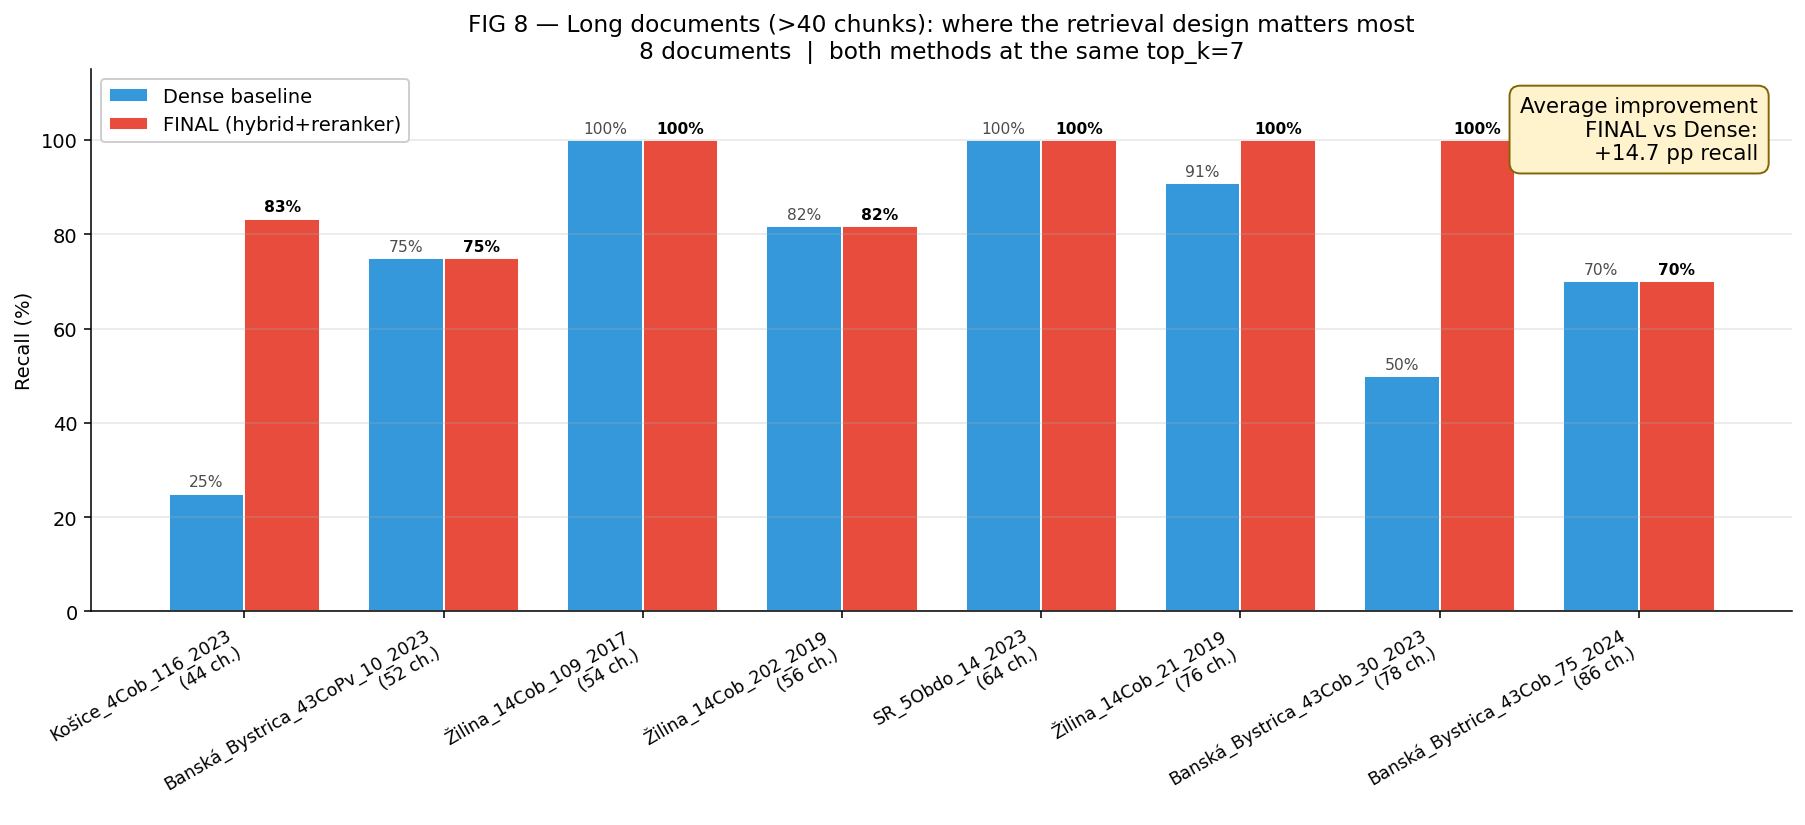


Long-document summary (8 documents >40 chunks):
  Dense baseline avg:          74.1% recall
  FINAL (hybrid+reranker):      88.8% recall
  Average improvement:          +14.7 percentage points


In [11]:
# FIG 8: Long documents focus — dense baseline vs FINAL config
LONG_THRESHOLD = 40

configs_compare = [
    ('openai3s_para_top7_w0',      'Dense baseline',        '#3498db'),
    ('hybrid_a7_reranked_top7_w0', 'FINAL (hybrid+reranker)', '#e74c3c'),
]

per_doc = {}
for exp, _, _ in configs_compare:
    rows = DETAILS[(DETAILS['experiment_name'] == exp) &
                    DETAILS['query_key'].str.contains('combined', na=False)]
    for doc in rows['document'].unique():
        sub = rows[rows['document'] == doc]
        per_doc.setdefault(doc, {})[exp] = (
            int(sub['total_doc_chunks'].max()),
            sub['quotes_found'].sum() / sub['quotes_expected'].sum() * 100
        )

long_data = []
for doc, vals in per_doc.items():
    if all(exp in vals for exp, _, _ in configs_compare):
        chunks = vals[configs_compare[0][0]][0]
        if chunks > LONG_THRESHOLD:
            short = doc.replace('_00_dokument.pdf', '').split('_', 1)[1] if '_' in doc else doc[:25]
            row = {'doc': short[:30], 'chunks': chunks}
            for exp, label, _ in configs_compare:
                row[label] = vals[exp][1]
            long_data.append(row)

long_df = pd.DataFrame(long_data).sort_values('chunks').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(long_df))
w = 0.38
labels = [c[1] for c in configs_compare]
colors_b = [c[2] for c in configs_compare]

for i, (label, color) in enumerate(zip(labels, colors_b)):
    bars = ax.bar(x + (i - 0.5) * w, long_df[label], w, label=label,
                  color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{bar.get_height():.0f}%', ha='center', fontsize=8,
                fontweight='bold' if 'FINAL' in label else 'normal',
                alpha=1.0 if 'FINAL' in label else 0.7)

xtick_labels = [f'{d}\n({c} ch.)' for d, c in zip(long_df['doc'], long_df['chunks'])]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Recall (%)')
ax.set_title(f'FIG 8 — Long documents (>{LONG_THRESHOLD} chunks): where the retrieval design matters most\n'
             f'{len(long_df)} documents  |  both methods at the same top_k=7')
ax.set_ylim(0, 115)
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

avg_imp = (long_df[labels[1]] - long_df[labels[0]]).mean()
ax.text(0.98, 0.95, f'Average improvement\nFINAL vs Dense:\n+{avg_imp:.1f} pp recall',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#856404'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/08_long_documents.png', bbox_inches='tight')
plt.show()

print(f'\nLong-document summary ({len(long_df)} documents >{LONG_THRESHOLD} chunks):')
print(f'  Dense baseline avg:          {long_df[labels[0]].mean():.1f}% recall')
print(f'  FINAL (hybrid+reranker):      {long_df[labels[1]].mean():.1f}% recall')
print(f'  Average improvement:          +{avg_imp:.1f} percentage points')

---
## 9. Vector embedding map — semantic separation of query groups

Question: does the embedding model understand the difference between
q1 (contract context), q2 (penalty rate), and q3 (moderation)?

I pick the document **KS_Banská_Bystrica_43Cob_30_2023** (78 chunks,
100 % recall on FINAL config, 82 % of selected chunks are unique to
one sub-query). I project all 78 chunks from the 1536-D OpenAI
embedding space into 2D using t-SNE, and in each panel I highlight the
chunks selected for one sub-query group.

If the embedding model truly distinguishes the 3 content types, the
coloured dots in each panel should form a compact cluster.

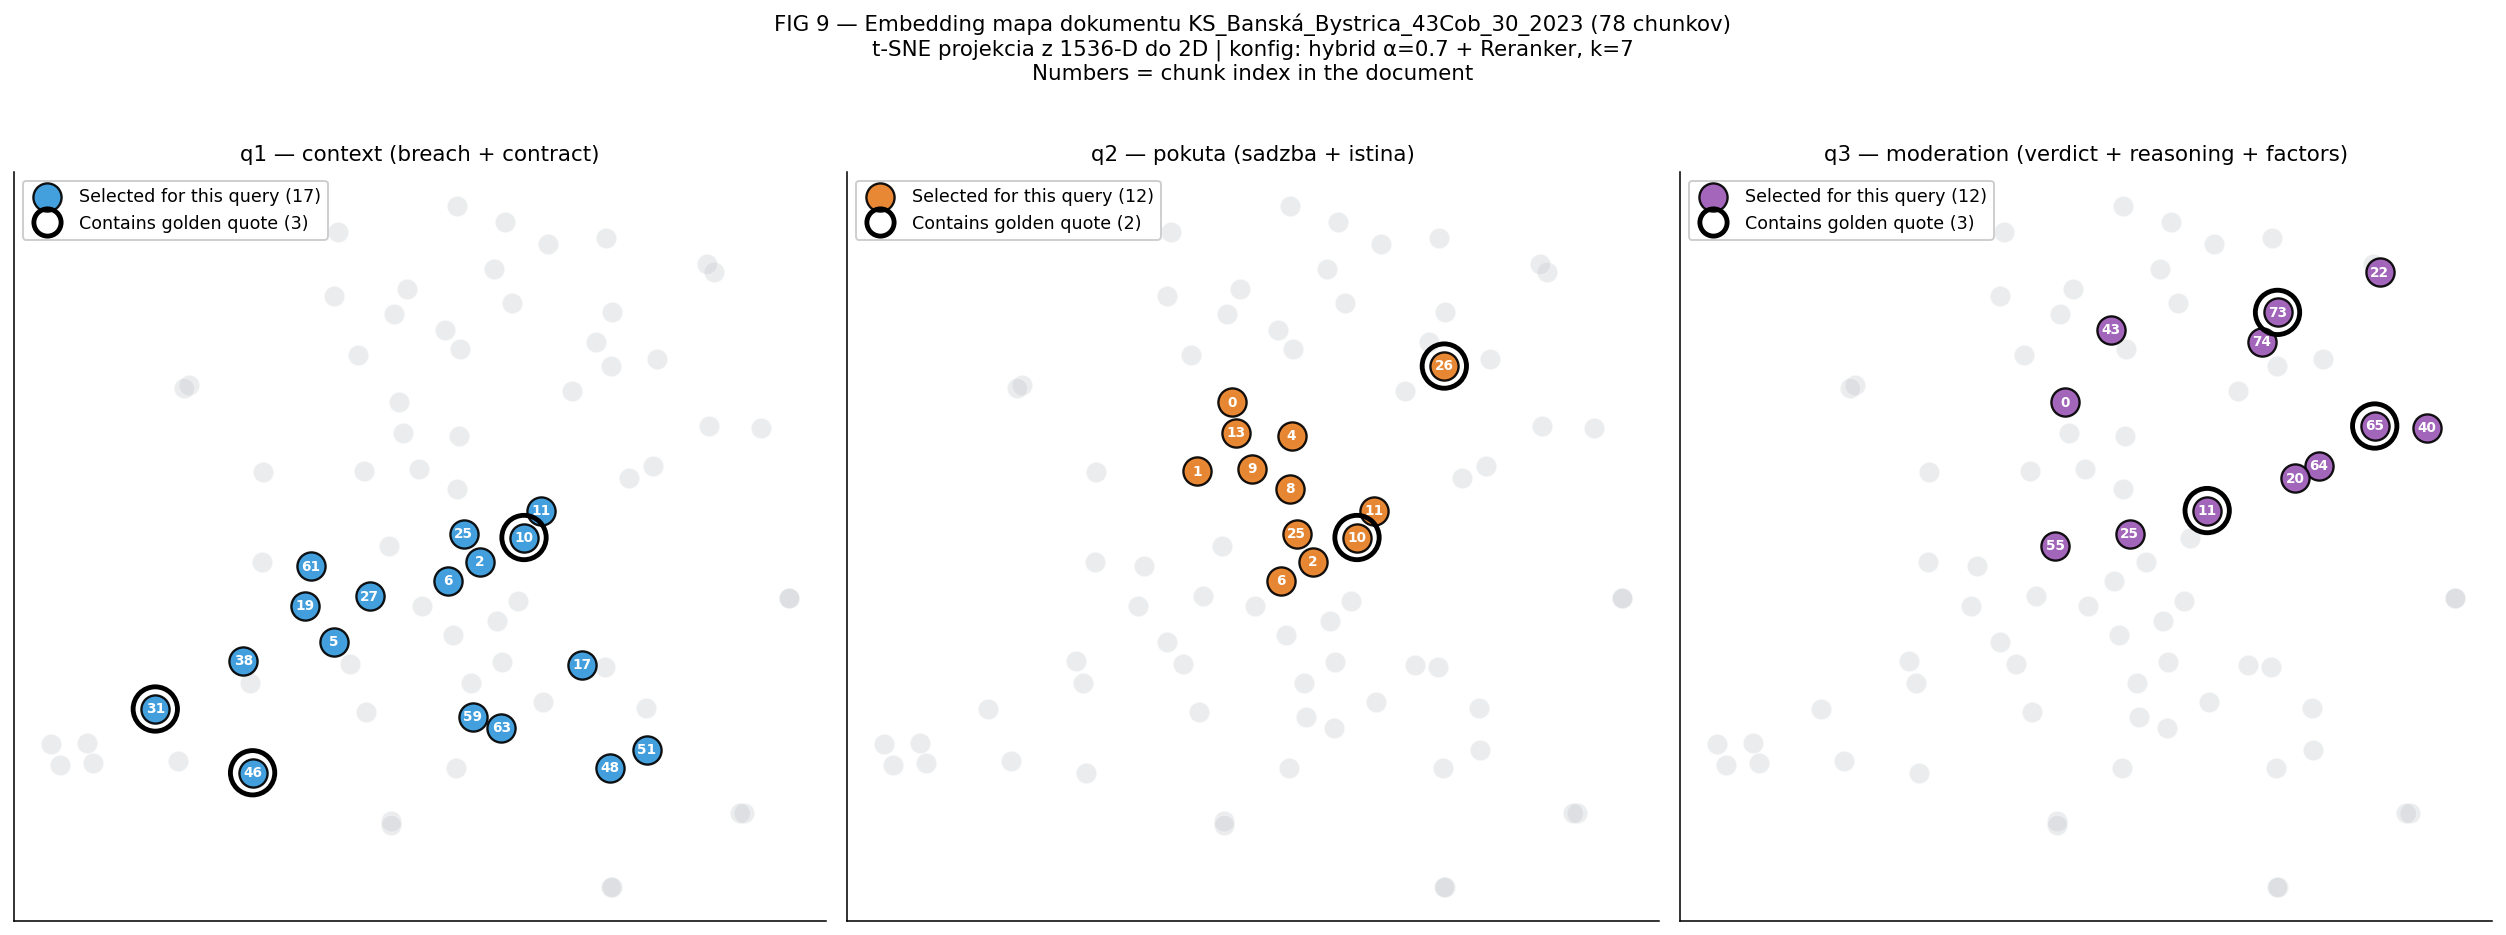


Clusters in each panel:
  q1 — context (breach + contrac  selected=17  golden=  3  hits=3/3
  q2 — pokuta (sadzba + istina)   selected=12  golden=  2  hits=2/2
  q3 — moderation (verdict + rea  selected=12  golden=  3  hits=3/3


In [12]:
# FIG 9: t-SNE embedding map of one document — 3 panels per query group
import json
TARGET_DOC = 'KS_Banská_Bystrica_43Cob_30_2023_00_dokument.pdf'

try:
    import chromadb
    from sklearn.manifold import TSNE
    from matplotlib.lines import Line2D
    import re

    client = chromadb.PersistentClient(path='../data/04_vectorstore')
    collection = client.get_collection('legal_decisions_openai_para')

    all_data = collection.get(
        where={'source_file': TARGET_DOC},
        include=['documents', 'metadatas', 'embeddings']
    )
    n_chunks = len(all_data['ids'])

    chunks_by_idx = {}
    for i in range(n_chunks):
        ci = all_data['metadatas'][i].get('chunk_index')
        chunks_by_idx[ci] = {
            'text':      all_data['documents'][i],
            'embedding': np.array(all_data['embeddings'][i]),
        }
    sorted_indices = sorted(chunks_by_idx.keys())
    embeddings = np.array([chunks_by_idx[i]['embedding'] for i in sorted_indices])

    perplexity = max(5, min(15, n_chunks // 5))
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42,
                init='pca', learning_rate='auto')
    coords = tsne.fit_transform(embeddings)

    # selected chunks per query group
    det_doc = DETAILS[(DETAILS['experiment_name'] == FINAL_EXP) &
                       (DETAILS['document'] == TARGET_DOC)]
    retrieved_per_group = {'q1_combined': set(), 'q2_combined': set(), 'q3_combined': set()}
    for _, r in det_doc.iterrows():
        qk = r['query_key']
        if qk in retrieved_per_group:
            try:
                ids = json.loads(r['retrieved_chunk_ids'])
                for cid in ids:
                    m = re.search(r'_chunk_(\d+)$', str(cid))
                    if m:
                        retrieved_per_group[qk].add(int(m.group(1)))
            except Exception:
                pass

    # golden chunks per group
    GOLDEN = pd.read_csv('../data/05_retrieval_evaluation/golden_dataset_template.csv', sep=';')
    golden_row = GOLDEN[GOLDEN['document_name'].str.contains(TARGET_DOC.replace('.pdf', ''))]
    golden_per_group = {'q1_combined': set(), 'q2_combined': set(), 'q3_combined': set()}
    quote_columns = {
        'q1_combined': 'q1_context_quotes',
        'q2_combined': 'q2_penalty_quotes',
        'q3_combined': 'q3_moderation_quotes',
    }
    if not golden_row.empty:
        for grp, col in quote_columns.items():
            val = str(golden_row.iloc[0].get(col, '')).strip()
            if val and val != 'nan':
                quotes = [q.strip() for q in val.split('|') if q.strip()]
                for ci in sorted_indices:
                    text = chunks_by_idx[ci]['text'].lower()
                    if any(q.lower() in text for q in quotes):
                        golden_per_group[grp].add(ci)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    group_colors = [
        ('q1_combined', 'q1 — context (breach + contract)',     '#3498db'),
        ('q2_combined', 'q2 — pokuta (sadzba + istina)',          '#e67e22'),
        ('q3_combined', 'q3 — moderation (verdict + reasoning + factors)', '#9b59b6'),
    ]
    short_doc = TARGET_DOC.replace('_00_dokument.pdf', '')

    for ax, (grp, title, color) in zip(axes, group_colors):
        selected = retrieved_per_group[grp]
        golden = golden_per_group[grp]

        # all chunks as light gray
        ax.scatter(coords[:, 0], coords[:, 1], s=110, c='#bdc3c7', alpha=0.3,
                   edgecolors='white', linewidth=0.7, zorder=2)

        # retrieved chunks for this group
        sel_pts = np.array([(coords[sorted_indices.index(c), 0],
                             coords[sorted_indices.index(c), 1])
                            for c in selected if c in sorted_indices])
        if len(sel_pts):
            ax.scatter(sel_pts[:, 0], sel_pts[:, 1], s=210, c=color, alpha=0.92,
                       edgecolors='black', linewidth=1.2, zorder=4,
                       label=f'Selected for this query ({len(selected)})')

        # circle golden chunks
        for ci in golden:
            if ci in sorted_indices:
                pos = sorted_indices.index(ci)
                ax.scatter(coords[pos, 0], coords[pos, 1],
                           s=520, facecolors='none', edgecolors='black',
                           linewidth=2.5, zorder=5)

        # number labels for selected/golden chunks
        labeled = selected | golden
        for ci in labeled:
            if ci in sorted_indices:
                pos = sorted_indices.index(ci)
                color_label = 'white' if ci in selected else 'black'
                ax.annotate(str(ci), (coords[pos, 0], coords[pos, 1]),
                            fontsize=7, ha='center', va='center', fontweight='bold',
                            color=color_label, zorder=6)

        extra = Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                       markeredgecolor='black', markersize=14, markeredgewidth=2.5,
                       label=f'Contains golden quote ({len(golden)})')
        handles, _ = ax.get_legend_handles_labels()
        handles.append(extra)
        ax.legend(handles=handles, loc='best', framealpha=0.95, fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(f'FIG 9 — Embedding mapa dokumentu {short_doc} ({n_chunks} chunkov)\n'
                 f't-SNE projekcia z 1536-D do 2D | konfig: hybrid α=0.7 + Reranker, k=7\n'
                 f'Numbers = chunk index in the document',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/09_embedding_map_3panels.png', bbox_inches='tight')
    plt.show()

    print('\nClusters in each panel:')
    for grp, label, _ in group_colors:
        sel = retrieved_per_group[grp]
        gold = golden_per_group[grp]
        hits = sel & gold
        print(f'  {label[:30]:<30s}  selected={len(sel):2d}  golden= {len(gold):2d}  hits={len(hits)}/{len(gold)}')

except Exception as e:
    print(f'⚠ FIG 9 skipped — ChromaDB not available or error: {e}')

---
## 10. HIT vs MISS score distribution — the uniform cosine problem

Question: why is dense alone not enough, why do we need BM25 + reranker?

For each retrieved chunk we know whether it contained a golden quote
(HIT) or not (MISS). If the score distributions of HIT and MISS chunks
overlap heavily, the retriever is deciding on a very thin margin —
embedding similarity alone cannot reliably tell relevant from
irrelevant.

This is the empirical motive for adding BM25 (a different ranking
signal) and the keyword reranker (domain-specific re-scoring).

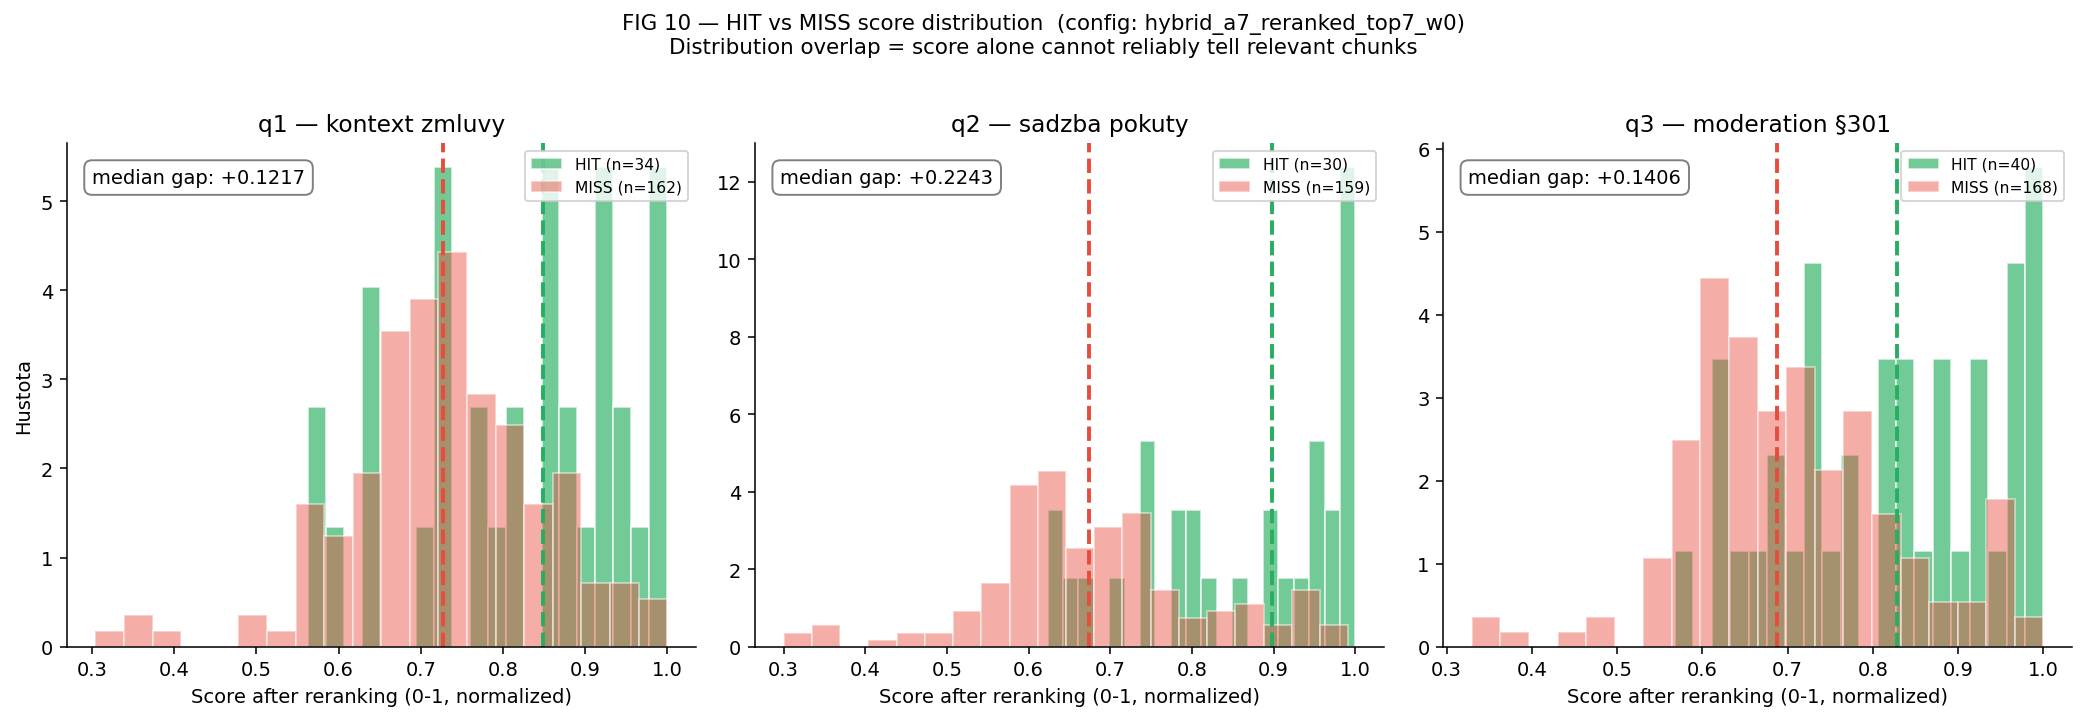


Median gaps between HIT and MISS:
  q1 — kontext zmluvy       HIT median=0.8490  MISS median=0.7273  gap=+0.1217
  q2 — sadzba pokuty        HIT median=0.8981  MISS median=0.6738  gap=+0.2243
  q3 — moderation §301      HIT median=0.8281  MISS median=0.6876  gap=+0.1406


In [13]:
# FIG 10: HIT vs MISS cosine distribution
import ast

final_det = DETAILS[DETAILS['experiment_name'] == FINAL_EXP].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panels = [
    ('q1_combined', 'q1 — kontext zmluvy'),
    ('q2_combined', 'q2 — sadzba pokuty'),
    ('q3_combined', 'q3 — moderation §301'),
]

for idx, (qkey, title) in enumerate(panels):
    rows = final_det[final_det['query_key'] == qkey]
    hit_scores, miss_scores = [], []
    for _, r in rows.iterrows():
        for col, target in [('hit_cosine_scores', hit_scores),
                            ('miss_cosine_scores', miss_scores)]:
            try:
                val = str(r.get(col, '')).strip()
                if val and val != 'nan' and val != '[]':
                    target.extend([float(x) for x in ast.literal_eval(val)])
            except Exception:
                pass

    ax = axes[idx]
    if hit_scores:
        ax.hist(hit_scores, bins=20, alpha=0.65, color='#27ae60',
                label=f'HIT (n={len(hit_scores)})', density=True, edgecolor='white')
        ax.axvline(np.median(hit_scores), color='#27ae60', linestyle='--', lw=2)
    if miss_scores:
        ax.hist(miss_scores, bins=20, alpha=0.45, color='#e74c3c',
                label=f'MISS (n={len(miss_scores)})', density=True, edgecolor='white')
        ax.axvline(np.median(miss_scores), color='#e74c3c', linestyle='--', lw=2)

    if hit_scores and miss_scores:
        gap = np.median(hit_scores) - np.median(miss_scores)
        ax.text(0.04, 0.95, f'median gap: {gap:+.4f}',
                transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray'))

    ax.set_xlabel('Score after reranking (0-1, normalized)')
    ax.set_ylabel('Hustota' if idx == 0 else '')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'FIG 10 — HIT vs MISS score distribution  (config: {FINAL_EXP})\n'
             'Distribution overlap = score alone cannot reliably tell relevant chunks',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/10_hit_miss_distribution.png', bbox_inches='tight')
plt.show()

print('\nMedian gaps between HIT and MISS:')
for qkey, label in panels:
    rows = final_det[final_det['query_key'] == qkey]
    h, m = [], []
    for _, r in rows.iterrows():
        try:
            h.extend([float(x) for x in ast.literal_eval(str(r.get('hit_cosine_scores', '[]')))])
            m.extend([float(x) for x in ast.literal_eval(str(r.get('miss_cosine_scores', '[]')))])
        except Exception:
            pass
    if h and m:
        print(f'  {label:<25s} HIT median={np.median(h):.4f}  MISS median={np.median(m):.4f}  '
              f'gap={np.median(h)-np.median(m):+.4f}')

---
## PAPER FIGURE 5 — 2×2 grid (paper version)

Main retrieval figure for the paper. The four panels match the key fair
comparisons from above:

| Panel | Shows | Isolates |
|---|---|---|
| (a) Chunking Pareto | fixed-size 200t / 500t vs PARA | chunking strategy |
| (b) Embedding model | mE5 vs OpenAI-S vs OpenAI-L | embedding model |
| (c) Methods Pareto | dense / BM25 / hybrid / +reranker | retrieval method |
| (d) Hier vs flat | alternative architecture | architecture (overlap zone) |

All 4 panels are fair comparisons under controlled isolation.

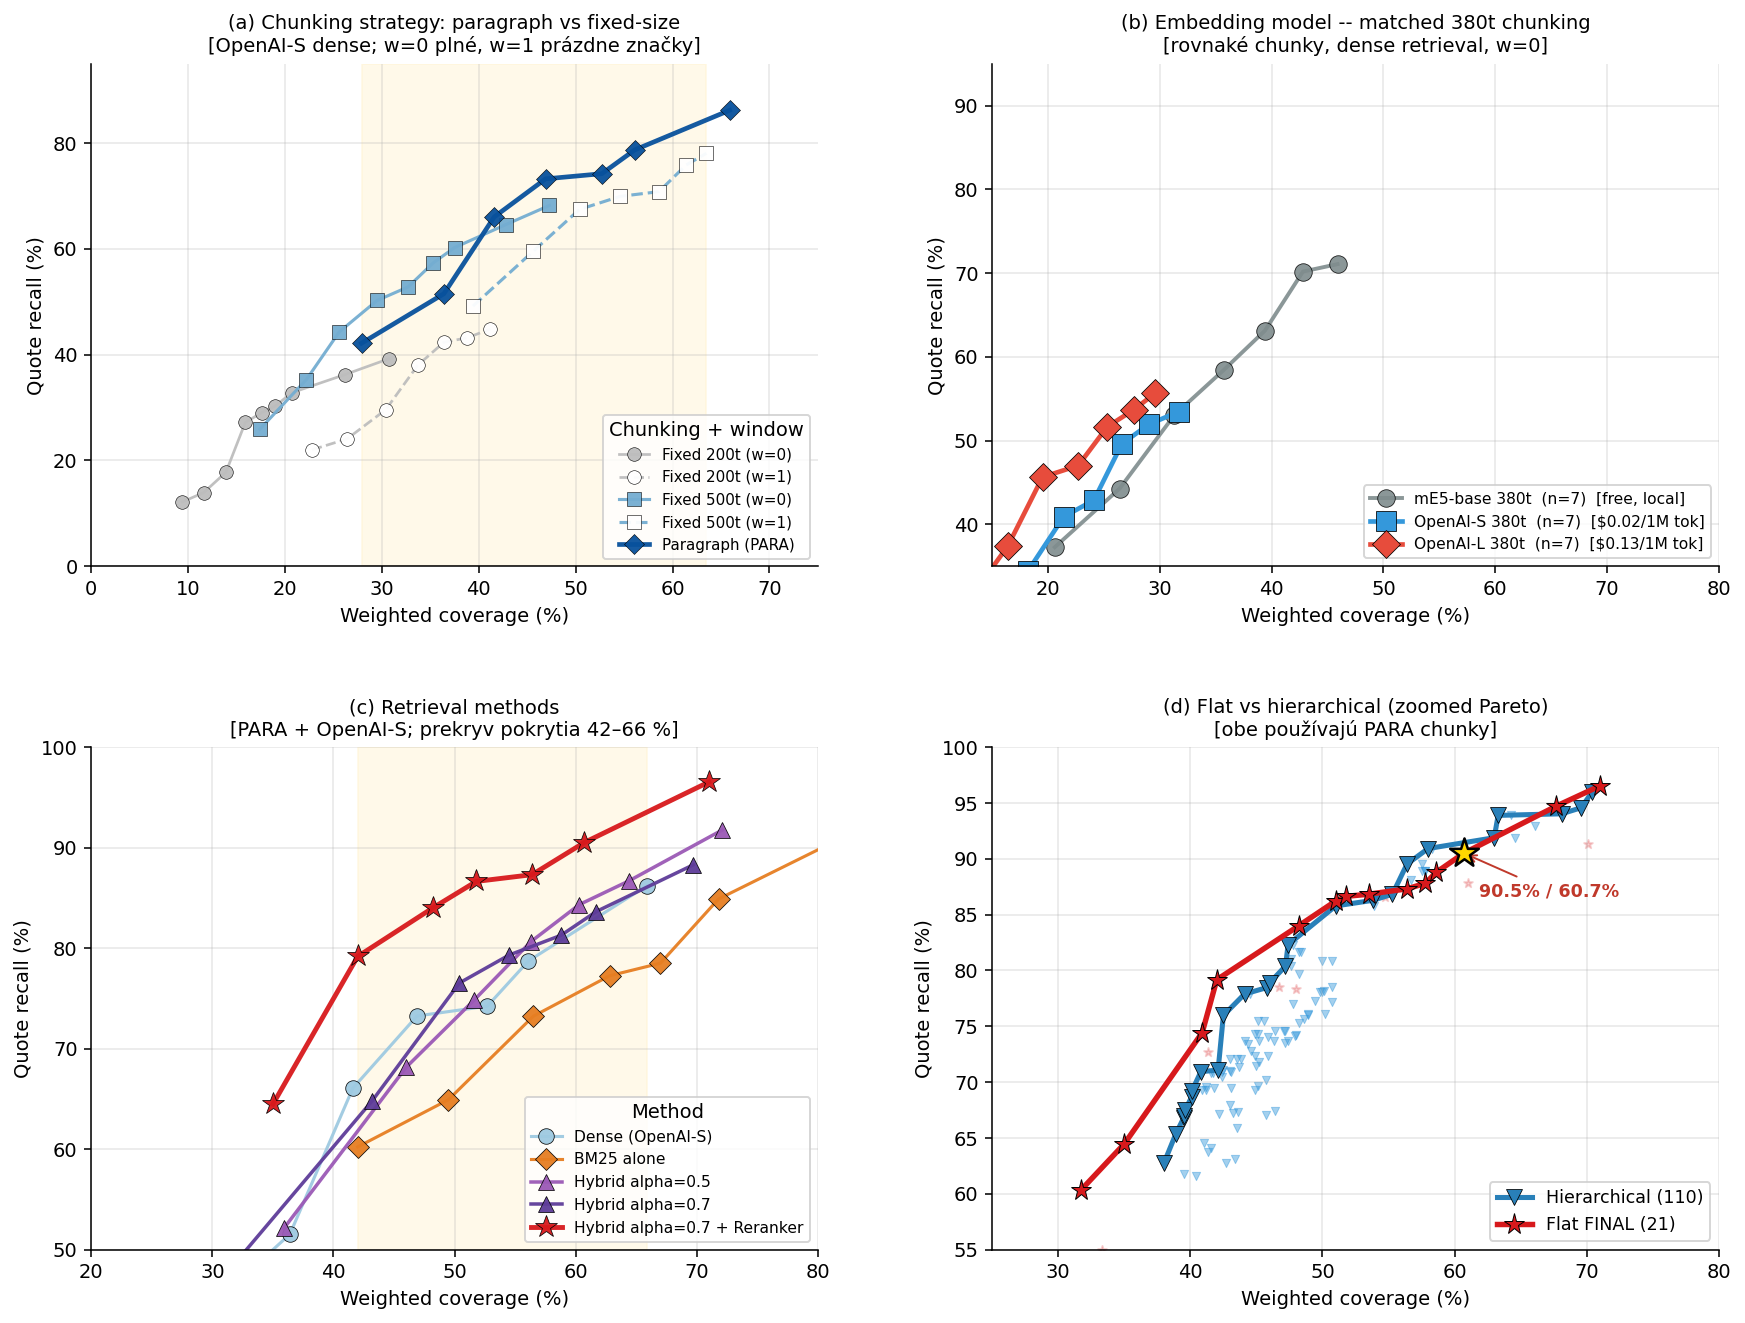

PAPER FIGURE 5: chunking | methods | topk | architectures (clean flat vs hier)


In [14]:
# PAPER FIGURE 5 - 2x2 grid (final paper version)
SUMMARY['is_reranked'] = SUMMARY['experiment_name'].str.contains('reranked')

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(2, 2, hspace=0.36, wspace=0.24)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ============================ (a) Chunking Pareto ============================
chunking_lines = [
    ('openai3s_200',  0, 'Fixed 200t (w=0)',   '#bdbdbd', 'o', '-',  1.4),
    ('openai3s_200',  1, 'Fixed 200t (w=1)',   '#bdbdbd', 'o', '--', 1.4),
    ('openai3s_500',  0, 'Fixed 500t (w=0)',   '#74add1', 's', '-',  1.6),
    ('openai3s_500',  1, 'Fixed 500t (w=1)',   '#74add1', 's', '--', 1.6),
    ('openai3s_para', 0, 'Paragraph (PARA)',   '#08519c', 'D', '-',  2.4),
]
for fam, w, lbl, c, m, ls, lw in chunking_lines:
    sub = SUMMARY[(SUMMARY['family']==fam) & (SUMMARY['window_size']==w)].sort_values('top_k')
    if sub.empty: continue
    ax_a.plot(sub['weighted_total_cov'], sub['recall_rate_percent'],
              marker=m, markersize=7, label=lbl, color=c, linewidth=lw, linestyle=ls,
              alpha=0.95, markeredgecolor='black', markeredgewidth=0.3,
              markerfacecolor=c if w==0 else 'white')

para_data = SUMMARY[(SUMMARY['family']=='openai3s_para') & (SUMMARY['window_size']==0)]
all_500 = SUMMARY[SUMMARY['family']=='openai3s_500']
ovl_min = max(all_500['weighted_total_cov'].min(), para_data['weighted_total_cov'].min())
ovl_max = min(all_500['weighted_total_cov'].max(), para_data['weighted_total_cov'].max())
ax_a.axvspan(ovl_min, ovl_max, color='#fff4d4', alpha=0.5, zorder=0)

ax_a.set_xlabel('Weighted coverage (%)', fontsize=10)
ax_a.set_ylabel('Quote recall (%)', fontsize=10)
ax_a.set_title('(a) Chunking strategy: paragraph vs fixed-size\n'
               '[OpenAI-S dense; w=0 plné, w=1 prázdne značky]', fontsize=10)
ax_a.legend(loc='lower right', fontsize=7.8, title='Chunking + window')
ax_a.grid(alpha=0.3)
ax_a.set_xlim(0, 75); ax_a.set_ylim(0, 95)

# ============================ (b) Embedding model -- matched 380t chunking ============================
# True ablation: same chunk size (380 tok) across all three models, same retrieval (dense),
# same window setting. Only difference is the embedding model itself.

me5_w0 = SUMMARY[(SUMMARY['family']=='mE5base_380') & (SUMMARY['window_size']==0)].sort_values('top_k')
oai_s_w0 = SUMMARY[(SUMMARY['family']=='openai3s_380') & (SUMMARY['window_size']==0)].sort_values('top_k')
oai_l_w0 = SUMMARY[(SUMMARY['family']=='openai3l_380') & (SUMMARY['window_size']==0)].sort_values('top_k')

if not me5_w0.empty:
    ax_b.plot(me5_w0['weighted_total_cov'], me5_w0['recall_rate_percent'],
              'o-', color='#7f8c8d', lw=2.0, ms=9, alpha=0.9,
              markeredgecolor='black', markeredgewidth=0.4,
              label=f'mE5-base 380t  (n={len(me5_w0)})  [free, local]')
if not oai_s_w0.empty:
    ax_b.plot(oai_s_w0['weighted_total_cov'], oai_s_w0['recall_rate_percent'],
              's-', color='#3498db', lw=2.4, ms=10,
              markeredgecolor='black', markeredgewidth=0.4,
              label=f'OpenAI-S 380t  (n={len(oai_s_w0)})  [$0.02/1M tok]')
if not oai_l_w0.empty:
    ax_b.plot(oai_l_w0['weighted_total_cov'], oai_l_w0['recall_rate_percent'],
              'D-', color='#e74c3c', lw=2.4, ms=10,
              markeredgecolor='black', markeredgewidth=0.4,
              label=f'OpenAI-L 380t  (n={len(oai_l_w0)})  [$0.13/1M tok]')

ax_b.set_xlabel('Weighted coverage (%)', fontsize=10)
ax_b.set_ylabel('Quote recall (%)', fontsize=10)
ax_b.set_title('(b) Embedding model -- matched 380t chunking\n'
               '[rovnaké chunky, dense retrieval, w=0]', fontsize=10)
ax_b.legend(loc='lower right', fontsize=8)
ax_b.grid(alpha=0.3)
ax_b.set_xlim(15, 80); ax_b.set_ylim(35, 95)

# ============================ (c) Retrieval methods ============================
method_fams = [
    ('openai3s_para',         'Dense (OpenAI-S)',                 '#9ecae1', 'o', 1.6),
    ('bm25_para',             'BM25 alone',                       '#e67e22', 'D', 1.6),
    ('hybrid_para',           'Hybrid alpha=0.5',                 '#9b59b6', '^', 1.8),
    ('hybrid_weighted_a7',    'Hybrid alpha=0.7',                 '#5e3c99', '^', 1.8),
    ('hybrid_a7_reranked',    'Hybrid alpha=0.7 + Reranker',      '#d7191c', '*', 2.5),
]
method_data = {}
for fam, lbl, c, m, lw in method_fams:
    sub = SUMMARY[(SUMMARY['family']==fam) & (SUMMARY['window_size']==0)].sort_values('weighted_total_cov')
    method_data[fam] = sub
    msize = 12 if m == '*' else 8
    ax_c.plot(sub['weighted_total_cov'], sub['recall_rate_percent'],
              marker=m, markersize=msize, label=lbl, color=c, linewidth=lw,
              alpha=0.95, markeredgecolor='black', markeredgewidth=0.4)

ovl_b_min = max(d['weighted_total_cov'].min() for d in method_data.values())
ovl_b_max = min(d['weighted_total_cov'].max() for d in method_data.values())
ax_c.axvspan(ovl_b_min, ovl_b_max, color='#fff4d4', alpha=0.5, zorder=0)

ax_c.set_xlabel('Weighted coverage (%)', fontsize=10)
ax_c.set_ylabel('Quote recall (%)', fontsize=10)
ax_c.set_title(f'(c) Retrieval methods\n'
               f'[PARA + OpenAI-S; prekryv pokrytia {ovl_b_min:.0f}–{ovl_b_max:.0f}\xa0%]', fontsize=10)
ax_c.legend(loc='lower right', fontsize=8, title='Method')
ax_c.grid(alpha=0.3)
ax_c.set_xlim(20, 80); ax_c.set_ylim(50, 100)

# ============================ (d) Flat (FINAL) vs hier - zoomed Pareto ============================
flat_rer = SUMMARY[(~SUMMARY['is_hier']) & (SUMMARY['is_reranked'])]
hier_all = SUMMARY[SUMMARY['is_hier']]

fpx_r, fpy_r = pareto_envelope(flat_rer)
hpx, hpy = pareto_envelope(hier_all)

ax_d.scatter(flat_rer['weighted_total_cov'], flat_rer['recall_rate_percent'],
             alpha=0.20, color='#d7191c', s=22, marker='*', zorder=1)
ax_d.scatter(hier_all['weighted_total_cov'], hier_all['recall_rate_percent'],
             alpha=0.45, color='#3498db', s=18, marker='v', linewidths=0.5, zorder=1)

ax_d.plot(hpx, hpy, '-', color='#2980b9', lw=2.6, marker='v', markersize=8,
          markeredgecolor='black', markeredgewidth=0.4,
          label=f'Hierarchical ({len(hier_all)})', zorder=5)
ax_d.plot(fpx_r, fpy_r, '-', color='#d7191c', lw=2.8, marker='*', markersize=11,
          markeredgecolor='black', markeredgewidth=0.5,
          label=f'Flat FINAL ({len(flat_rer)})', zorder=6)

# FINAL marker — zmensena hviezdicka, len statistika bez slova "FINAL"
final_row = SUMMARY[SUMMARY['experiment_name'] == FINAL_EXP].iloc[0]
ax_d.scatter([final_row['weighted_total_cov']], [final_row['recall_rate_percent']],
             marker='*', s=240, color='gold', edgecolors='black', linewidths=1.3, zorder=15)
ax_d.annotate(f'90.5% / 60.7%',
              xy=(final_row['weighted_total_cov'], final_row['recall_rate_percent']),
              xytext=(8, -22), textcoords='offset points',
              fontsize=9, color='#c0392b', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0))

ax_d.set_xlabel('Weighted coverage (%)', fontsize=10)
ax_d.set_ylabel('Quote recall (%)', fontsize=10)
ax_d.set_title('(d) Flat vs hierarchical (zoomed Pareto)\n'
               '[obe používajú PARA chunky]',
               fontsize=10)
ax_d.legend(loc='lower right', fontsize=9)
ax_d.grid(alpha=0.3)
ax_d.set_xlim(25, 80); ax_d.set_ylim(55, 100)

plt.savefig(f'{FIGURES_DIR}/PAPER_obr5_retrieval_grid.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/PAPER_obr5_retrieval_grid.png', dpi=200, bbox_inches='tight')
plt.show()

print('PAPER FIGURE 5: chunking | methods | topk | architectures (clean flat vs hier)')


---
## PAPER TABLE 2 — milestones

At the same k=7 (fixed-k budget). Coverage is shown explicitly in the
table, so the reader sees at which coverage budget the table numbers hold.

In [15]:
# TABLE 2: milestones with Δ column showing recall change vs previous step
MILESTONES = [
    ('mE5_380 dense (k=7, w=0)',          'mE5base_380_top7_w0'),
    ('mE5_380 dense (k=7, w=1)',          'mE5base_380_top7_w1'),
    ('OpenAI-S 500t dense',               'openai3s_500_top7_w0'),
    ('OpenAI-S PARA dense',               'openai3s_para_top7_w0'),
    ('OpenAI-L PARA dense',               'openai3l_para_top7_w0'),
    ('OpenAI-S PARA BM25',                'bm25_para_top7_w0'),
    ('Hybrid α=0.5 (RRF)',                'hybrid_para_top7_w0'),
    ('Hybrid α=0.7',                      'hybrid_weighted_a7_top7_w0'),
    ('Hybrid α=0.7 + Reranker (FINAL)',   'hybrid_a7_reranked_top7_w0'),
    ('Best hierarchical (any k, w=0)',    None),  # special: best from hier set
]
rows = []
prev_recall = None
for label, exp in MILESTONES:
    if exp is None:
        h = SUMMARY[SUMMARY['is_hier'] & (SUMMARY['window_size'] == 0)]
        r = h.loc[h['recall_rate_percent'].idxmax()]
    else:
        rr = SUMMARY[SUMMARY['experiment_name'] == exp]
        if rr.empty:
            rows.append({'Configuration': label, 'Recall': '—', 'Coverage': '—',
                         'Δ Recall': '—', 'MRR': '—', 'Eff. (R/C)': '—'})
            continue
        r = rr.iloc[0]
    eff = r['recall_rate_percent'] / r['weighted_total_cov'] if r['weighted_total_cov'] > 0 else 0

    # delta vs previous
    if prev_recall is None:
        delta_str = '—'  # baseline
    else:
        delta = r['recall_rate_percent'] - prev_recall
        delta_str = f"{delta:+.1f} pp" if abs(delta) >= 0.05 else "= 0"

    rows.append({
        'Configuration': label,
        'Recall':       f"{r['recall_rate_percent']:.1f}%",
        'Coverage':     f"{r['weighted_total_cov']:.1f}%",
        'Δ Recall':     delta_str,
        'MRR':          f"{r['avg_mrr']:.3f}" if pd.notna(r['avg_mrr']) else '—',
        'Eff. (R/C)':   f"{eff:.2f}",
    })
    prev_recall = r['recall_rate_percent']

tab2 = pd.DataFrame(rows)
print(tab2.to_string(index=False))
print()
print('Δ Recall = change in recall vs the previous row (cumulative progression).')
final_r = float(tab2.iloc[8]['Recall'].rstrip('%'))
base_r = float(tab2.iloc[0]['Recall'].rstrip('%'))
print(f'Total improvement from mE5 baseline ({base_r:.1f} %) to FINAL ({final_r:.1f} %): '
      f'+{final_r - base_r:.1f} pp = cumulative accumulation of all improvements.')

tab2

                  Configuration Recall Coverage Δ Recall   MRR Eff. (R/C)
       mE5_380 dense (k=7, w=0)  70.2%    42.8%        — 0.333       1.64
       mE5_380 dense (k=7, w=1)  84.5%    71.9% +14.3 pp 0.473       1.17
            OpenAI-S 500t dense  57.4%    35.3% -27.1 pp 0.289       1.62
            OpenAI-S PARA dense  78.7%    56.1% +21.4 pp 0.349       1.40
            OpenAI-L PARA dense  81.1%    51.2%  +2.3 pp 0.474       1.58
             OpenAI-S PARA BM25  84.9%    71.8%  +3.8 pp 0.545       1.18
             Hybrid α=0.5 (RRF)  86.7%    64.4%  +1.8 pp 0.524       1.35
                   Hybrid α=0.7  83.6%    61.7%  -3.0 pp 0.457       1.36
Hybrid α=0.7 + Reranker (FINAL)  90.5%    60.7%  +6.9 pp 0.717       1.49
 Best hierarchical (any k, w=0)  96.0%    70.4%  +5.5 pp     —       1.36

Δ Recall = change in recall vs the previous row (cumulative progression).
Total improvement from mE5 baseline (70.2 %) to FINAL (90.5 %): +20.3 pp = cumulative accumulation of all impro

,Configuration,Recall,Coverage,Δ Recall,MRR,Eff. (R/C)
0,"mE5_380 dense (k=7, w=0)",70.2%,42.8%,—,0.333,1.64
1,"mE5_380 dense (k=7, w=1)",84.5%,71.9%,+14.3 pp,0.473,1.17
2,OpenAI-S 500t dense,57.4%,35.3%,-27.1 pp,0.289,1.62
3,OpenAI-S PARA dense,78.7%,56.1%,+21.4 pp,0.349,1.40
4,OpenAI-L PARA dense,81.1%,51.2%,+2.3 pp,0.474,1.58
5,OpenAI-S PARA BM25,84.9%,71.8%,+3.8 pp,0.545,1.18
6,Hybrid α=0.5 (RRF),86.7%,64.4%,+1.8 pp,0.524,1.35
7,Hybrid α=0.7,83.6%,61.7%,-3.0 pp,0.457,1.36
8,Hybrid α=0.7 + Reranker (FINAL),90.5%,60.7%,+6.9 pp,0.717,1.49
9,"Best hierarchical (any k, w=0)",96.0%,70.4%,+5.5 pp,—,1.36


---
## Summary

All main comparisons are made at comparable coverage via Pareto curves:

| # | Isolation | Main finding |
|---|---|---|
| 1 | Chunking (FIG 1) | In the overlap zone 500t and PARA are comparable; at cov ≥ 50 % PARA dominates by +6-8 pp; only PARA reaches cov ≥ 65 % |
| 2 | Methods (FIG 2) | In the overlap zone of all 5 methods (cov 42-66 %): Hybrid α=0.7 + Reranker dominates at every matched cov by 5-15 pp |
| 3 | Reranker isolation (FIG 3) | At equal α=0.7: +6.9 pp recall, -1.0 pp coverage |
| 4 | Architectures (FIG 4) | Hier ≈ flat (no reranker) in the overlap zone 45-55 %; reranker is an orthogonal effect +5-7 pp; flat saturates around cov ~57 % |
| 5 | Top-k (FIG 5) | Sweet spot k=7; k=10 brings +6 pp recall for +10 pp coverage |
| 6 | Global overview (FIG 6) | The production configuration is a practical compromise: high recall at coverage that is still useful for RAG extraction |

Final configuration: `hybrid α=0.7 + reranker, PARA chunking, OpenAI-S, k=7, w=0`
- recall 90.5 % at coverage 60.7 %
- MRR 0.717, efficiency 1.49

Claims for the paper:

1. Chunking: paragraph chunking respects the semantic boundaries of
   legal arguments and dominates fixed-size at every reachable
   high-coverage budget (≥ 50 %).

2. Methods: hybrid retrieval (BM25 + dense via weighted RRF α=0.7) +
   domain-specific keyword reranker is the optimal method in the
   overlap zone at every matched coverage budget.

3. Architecture: flat paragraph chunking and the hierarchical
   parent-child architecture are competitive in the overlap zone
   (cov 45-55 %). Hier saturates around ~57 % (paragraph count cap)
   while flat keeps growing. The reranker is an orthogonal effect
   independent of the architecture, contributing +5-7 pp at matched cov.

4. Top-k: k=7 is the Pareto-optimal sweet spot for the FINAL config
   (90.5 % recall at 60.7 % cov).

Paper figures:
- `PAPER_obr5_retrieval_grid.{pdf,png}` — 2×2 grid

Exploratory PNGs (for the thesis):
- `01_chunking_pareto.png` (FIG 1)
- `01b_embedding_models.png` (FIG 1b)
- `02_methods_pareto.png` (FIG 2)
- `02_bm25_dense_complementarity.png` (aside)
- `03_reranker_impact.png` (FIG 3)
- `04_hierarchical_vs_flat.png` (FIG 4)
- `05_topk_progression.png` (FIG 5)
- `06_overview_pareto.png` (FIG 6)
- `07_per_document.png` (FIG 7)
- `08_long_documents.png` (FIG 8)
- `09_embedding_map_3panels.png` (FIG 9)
- `10_hit_miss_distribution.png` (FIG 10)